
# Clase 5 — Aprendizaje No Supervisado: Notebook práctico
# **Autor:** Prof. Dr. Pástor E Pérez Estigarribia
# **Objetivo:** Complementar la clase teórica con ejercicios prácticos de clustering, PCA y detección de anomalías usando scikit-learn.
#
# **Secciones**
# 1. Imports y configuración
# 2. Carga y preprocesamiento de datasets
# 3. Funciones utilitarias para gráficos y guardado de figuras
# 4. Ejercicios guiados (Iris, moons, Wine/Digits, outliers sintéticos)
# 5. Evaluación y resumen
# 6. Widgets interactivos y checklist de entrega

Nota: Utiliza la notebookLM para comprender el codigo demostrativo inicial y/o la función de explicar código de colab


In [165]:
# %%
# 1) Imports y configuración
# Instalar ipywidgets en Colab si es necesario:
!pip install ipywidgets --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons, make_circles, make_blobs
import ipywidgets as widgets
from IPython.display import display, clear_output

import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid', context='notebook', rc={'figure.figsize':(8,5)})
RND = 42
np.random.seed(RND)

# Crear carpeta de figuras
os.makedirs('figures', exist_ok=True)


Tarea - Comenta que taréa se implmento en la celda anterior:

# 2) **Carga y preparación de datasets**
# Cargamos Iris, Wine, make_moons, make_circles y Digits (submuestra si es necesario).
# Escalamos con StandardScaler y guardamos variables con sufijo _s.


In [166]:
# %%
# Iris
iris = datasets.load_iris()
X_iris = iris.data
y_iris = iris.target
scaler = StandardScaler()
X_iris_s = scaler.fit_transform(X_iris)

# Wine
wine = datasets.load_wine()
X_wine = wine.data
y_wine = wine.target
X_wine_s = scaler.fit_transform(X_wine)

# Moons and circles (no lineales)
X_moons, y_moons = make_moons(n_samples=500, noise=0.08, random_state=RND)
X_circles, y_circles = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=RND)
X_moons_s = scaler.fit_transform(X_moons)
X_circles_s = scaler.fit_transform(X_circles)

# Digits submuestra
digits = datasets.load_digits()
X_digits = digits.data
y_digits = digits.target
if X_digits.shape[0] > 1000:
    idx = np.random.choice(X_digits.shape[0], 1000, replace=False)
    X_digits = X_digits[idx]
    y_digits = y_digits[idx]
X_digits_s = scaler.fit_transform(X_digits)


Tarea - Comenta que taréa se implmento en la celda anterior:

# **3) Funciones utilitarias**
# Definimos las funciones solicitadas que guardan las figuras con los nombres exactos.


In [167]:
import math
from matplotlib.patches import Ellipse

Tarea - Comenta que taréa se implmento en la celda anterior:

### Visualización PCA 2D — `plot_pca_scatter`

**Propósito**  
Proyectar los datos $X$ sobre las dos primeras componentes principales mediante PCA, dibujar un scatter coloreado por `labels`, anotar los ejes como PC1 y PC2 con su porcentaje de varianza explicada y guardar la figura en `filename`.

---

### Entradas esperadas
- **`X`**: matriz de datos de forma $n\times d$ (filas = observaciones, columnas = variables).  
- **`labels`**: vector de longitud $n$ con etiquetas o categorías para colorear los puntos.  
- **`filename`**: ruta donde se guardará la figura (PNG).  
- **`title`**: título del gráfico.

**Recomendación previa:** escalar las variables antes de PCA (por ejemplo con `StandardScaler`) si las características están en distintas unidades o escalas.

---

### Pasos computacionales
1. Ajustar PCA con $2$ componentes y obtener la proyección
   $$
   Z = \text{PCA}_{2}(X)\in\mathbb{R}^{n\times 2}.
   $$
2. Calcular la fracción de varianza explicada para cada componente:
   $$
   \mathrm{EVR}_k=\frac{\lambda_k}{\sum_{j=1}^d \lambda_j},
   $$
   donde $\lambda_k$ es el autovalor de la $k$-ésima componente.
3. Dibujar el scatter $Z[:,0]$ vs $Z[:,1]$, coloreando por `labels` y añadiendo una barra de color.
4. Guardar la figura en `filename` y cerrar la figura para liberar memoria.

---

### Interpretación visual
- **Posición de puntos:** proximidad en el plano PC1–PC2 indica similitud en las combinaciones lineales que explican mayor varianza.  
- **Separación por color:** si las etiquetas forman grupos bien separados, las dos primeras componentes capturan la estructura de clase/cluster.  
- **Porcentaje en ejes:** si $\mathrm{EVR}_1+\mathrm{EVR}_2$ es alto (p. ej. $>75\%$), el plano resume la mayor parte de la variabilidad; si es bajo (p. ej. $<50\%$), la visualización puede ser insuficiente.  
- **Limitación:** PCA es lineal; si la estructura es no lineal, considerar t‑SNE o UMAP para visualización.

---

### Notas prácticas
- Indicar explícitamente si $X$ ya está escalada; si no, sugerir:
  ```python
  from sklearn.preprocessing import StandardScaler
  X = StandardScaler().fit_transform(X)


In [168]:
def plot_pca_scatter(X, labels, filename='figures/pca_projection.png', title='PCA 2D'):
    """
    Proyecta X con PCA(2), grafica scatter coloreado por labels y guarda en filename.
    """
    pca = PCA(n_components=2, random_state=RND)
    Z = pca.fit_transform(X)
    fig, ax = plt.subplots(figsize=(7,6))
    scatter = ax.scatter(Z[:,0], Z[:,1], c=labels, cmap='tab10', s=40, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.show()
    plt.close(fig)

Tarea - Comenta que taréa se implmento en la celda anterior:

### PCA Biplot — `plot_pca_biplot`

**Propósito**  
Escalar y centrar $X$, proyectarla con PCA(2), dibujar un scatter coloreado por `labels` y superponer los vectores (loadings) de las variables originales para interpretar contribuciones y correlaciones en el plano PC1–PC2. La celda guarda la figura en `filename`.

---

### Entradas esperadas
- **`X`**: matriz de datos $n\times d$ (filas = observaciones, columnas = variables).  
- **`labels`**: vector de longitud $n$ con etiquetas o categorías para colorear los puntos.  
- **`feature_names`**: lista de nombres de variables (opcional).  
- **`filename`**: ruta donde se guardará la figura (PNG).  
- **`title`**: título del gráfico.

**Recomendación previa:** siempre escalar las variables (por ejemplo con `StandardScaler`) si están en distintas unidades.

---

### Qué hace la función (pasos conceptuales)
1. Centra y escala columnas: $X_{\text{scaled}}=\text{StandardScaler}(X)$.  
2. Ajusta PCA con 2 componentes y obtiene la proyección
   $$
   Z = \text{PCA}_2(X_{\text{scaled}})\in\mathbb{R}^{n\times 2}.
   $$
3. Calcula los \emph{loadings} (vectores de carga) escalados por la raíz de la varianza explicada:
   $$
   A = W_{(2)}\,\Lambda_{(2)}^{1/2},
   $$
   donde $W_{(2)}$ son las primeras dos columnas de autovectores y $\Lambda_{(2)}=\operatorname{diag}(\lambda_1,\lambda_2)$. En código esto corresponde a `loadings = pca.components_.T * np.sqrt(pca.explained_variance_)`.
4. Dibuja el scatter de $Z$ coloreado por `labels` y superpone flechas desde el origen hasta cada columna $a_j$ de $A$ para representar las variables en el plano.
5. Guarda la figura en `filename` y cierra la figura.

---

### Interpretación práctica
- **Dirección del vector**: indica la combinación lineal de variables que define la dirección en el plano; vectores con direcciones similares implican variables correlacionadas.  
- **Ángulo entre vectores**: el coseno del ángulo aproxima la correlación entre variables (para datos centrados o cargas normalizadas).  
- **Longitud del vector**: en este escalado (multiplicando por $\Lambda^{1/2}$) la longitud al cuadrado
  $$
  \|a_j\|^2 = a_j^\top a_j = w^{(j)\top}_{(2)}\,\Lambda_{(2)}\,w^{(j)}_{(2)}
  $$
  representa la varianza de la variable $j$ explicada por las dos primeras componentes. Vectores largos → gran varianza explicada por el plano; vectores cortos → poca varianza en el plano (información en componentes posteriores).
- **Escala visual**: a veces conviene multiplicar los loadings por un factor de escala para mejorar visibilidad; documenta cualquier factor aplicado.

---

### Notas prácticas y recomendaciones
- Mostrar en los ejes los porcentajes de varianza explicada: `PC1 (xx.x%)`, `PC2 (yy.y%)`.  
- Si $ \mathrm{EVR}_1 + \mathrm{EVR}_2 $ es bajo, el biplot resume poca variabilidad; complementa con más componentes o con otras técnicas (t‑SNE/UMAP) para visualización.  
- Para comparar longitudes entre variables, reporta la **fracción** de varianza explicada por las dos componentes:
  $$
  \text{fracción}_j = \frac{\|a_j\|^2}{\mathrm{Var}_{\text{total}}(j)}.
  $$
- Si `labels` son categorías nominales, añade leyenda; usa paletas con buen contraste y considera accesibilidad de colores.  
- Documenta cualquier tratamiento previo (imputación, transformación, outliers removidos) para reproducibilidad.

---
Esta celda centra y escala $X$, aplica PCA(2), grafica las proyecciones en PC1–PC2 coloreadas por `labels` y superpone los vectores de carga de las variables (escalados por $\Lambda^{1/2}$). En este escalado la longitud de cada vector refleja la varianza de la variable explicada por el plano mostrado; el ángulo entre vectores aproxima la correlación entre variables. Asegúrate de que $X$ esté escalada y anota los porcentajes de varianza explicada en los ejes.


In [169]:
def plot_pca_biplot(X, labels, feature_names=None, filename='figures/pca_biplot.png', title='PCA Biplot'):
    """
    Escala y centra X, proyecta con PCA(2), grafica scatter coloreado por labels
    y superpone los vectores (loadings) de las variables originales.
    """
    # Centrado y escalado de las columnas
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2, random_state=RND)
    Z = pca.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(8,7))
    scatter = ax.scatter(Z[:,0], Z[:,1], c=labels, cmap='tab10', s=40, alpha=0.8)

    # Vectores de carga (loadings) escalados por la varianza explicada
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

    if feature_names is None:
        feature_names = [f'Var{i+1}' for i in range(X.shape[1])]

    for i, feature in enumerate(feature_names):
        ax.arrow(0, 0, loadings[i, 0], loadings[i, 1], color='r', alpha=0.6,
                 head_width=0.05, head_length=0.05)
        ax.text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15, feature,
                color='darkred', ha='center', va='center', fontsize=10)

    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.show()
    plt.close(fig)


Tarea - Comenta que taréa se implmento en la celda anterior:

### Elbow y Silhouette — `plot_elbow_silhouette`

**Propósito**  
Calcular la inercia (WCSS) y el Silhouette score medio para una gama de valores $k$, graficar ambas curvas en un mismo panel y guardar la figura en `'{save_path_prefix}.png'`. Devuelve $(\text{Ks},\ \text{sse},\ \text{sil})$ para análisis posterior.

---

### Entradas esperadas
- **`X`**: matriz de datos $n\times d$ (filas = observaciones, columnas = variables).  
- **`k_range`**: iterable de valores enteros de $k$ a evaluar (por ejemplo `range(1,11)`).  
- **`save_path_prefix`**: prefijo de ruta para guardar la figura; la función guarda `'{save_path_prefix}.png'`.

**Recomendación previa:** escalar las variables (por ejemplo con `StandardScaler`) si las características están en distintas unidades.

---

### Definiciones matemáticas
- **Inercia (WCSS)** para una partición en $K$ clusters:
$$
\text{WCSS}(K)=\sum_{k=1}^{K}\sum_{x_i\in C_k}\|x_i-\mu_k\|^2,
$$
donde $\mu_k$ es el centroide del clúster $C_k$. La curva WCSS vs $K$ suele mostrar un "codo" donde la mejora se atenúa.

- **Coeficiente de Silhouette** para una muestra $i$:
$$
s(i)=\frac{b(i)-a(i)}{\max\{a(i),\,b(i)\}},
$$
donde $a(i)$ es la distancia media de $i$ a los puntos de su propio clúster (cohesión) y $b(i)$ es la mínima distancia media a puntos de otro clúster (separación). El Silhouette medio se obtiene promediando $s(i)$ sobre todas las muestras.

---

### Qué hace la celda (pasos conceptuales)
1. Para cada $k\in\text{Ks}$ ajusta `KMeans(n_clusters=k)` y guarda la inercia `km.inertia_` en `sse`.  
2. Calcula el Silhouette score medio con `silhouette_score(X, km.labels_)` para $k>1$ y lo guarda en `sil` (para $k=1$ no existe Silhouette, se usa `NaN`).  
3. Dibuja en un mismo gráfico: WCSS (eje izquierdo, color azul) y Silhouette medio (eje derecho, color verde).  
4. Añade títulos y etiquetas claras: eje $x$ = "Número de clusters $k$", eje izquierdo = "Inercia (WCSS)", eje derecho = "Silhouette score medio".  
5. Guarda la figura en `'{save_path_prefix}.png'`, muestra la figura y cierra el objeto para liberar memoria.  
6. Devuelve arrays `Ks`, `sse`, `sil` para análisis o trazados adicionales.

---

### Interpretación práctica
- **Elbow (WCSS):** buscar el punto donde la reducción de WCSS al aumentar $k$ se vuelve marginal (el "codo"). Ese rango sugiere candidatos para $k$.  
- **Silhouette medio:** valores cercanos a $1$ indican particiones bien separadas; valores negativos indican asignaciones pobres. Usar Silhouette para validar y afinar la elección de $k$ dentro del rango sugerido por Elbow.  
- **Uso combinado:** usar Elbow para acotar candidatos y Silhouette para seleccionar el $k$ con mejor separación media. Si ambos criterios coinciden, la elección es más robusta.

---

### Notas prácticas y recomendaciones
- Para estabilidad, ejecutar KMeans varias veces (`n_init>=10`) y fijar `random_state` para reproducibilidad.  
- Silhouette es costoso en tiempo para grandes $n$ (complejidad en distancias); para datasets grandes considerar muestreo representativo.  
- Visualizar además el *silhouette plot* por muestra y un scatter en espacio PCA para inspección cualitativa.  
- Documentar la decisión final (por qué se eligió $k$) y comprobar sensibilidad cambiando la semilla o usando otros algoritmos (GMM, DBSCAN).

---

Esta celda calcula la inercia (WCSS) y el Silhouette score medio para cada $k$ en `k_range`, grafica ambas curvas en un mismo panel (WCSS en eje izquierdo, Silhouette en eje derecho), guarda la figura en `'{save_path_prefix}.png'` y devuelve `(Ks, sse, sil)`. Usa Elbow para acotar candidatos y Silhouette para validar la separación; para grandes muestras considera muestreo por rendimiento.


In [170]:
def plot_elbow_silhouette(X, k_range, save_path_prefix='figures/elbow_and_silhouette'):
    """
    Calcula inercia y silhouette para cada k en k_range, grafica ambas curvas
    y guarda la figura como '{save_path_prefix}.png'.
    Devuelve (Ks, sse, sil).
    """
    Ks = list(k_range)
    sse = []
    sil = []
    for k in Ks:
        km = KMeans(n_clusters=k, random_state=RND, n_init=10).fit(X)
        sse.append(km.inertia_)
        if k > 1:
            sil.append(silhouette_score(X, km.labels_))
        else:
            sil.append(np.nan)
    fig, ax1 = plt.subplots(figsize=(9,5))
    color = 'tab:blue'
    ax1.set_xlabel('Número de clusters k')
    ax1.set_ylabel('Inercia (WCSS)', color=color)
    ax1.plot(Ks, sse, marker='o', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.set_ylabel('Silhouette score medio', color=color)
    ax2.plot(Ks, sil, marker='s', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    plt.title('Elbow (Inercia) y Silhouette score vs k')
    plt.tight_layout()
    fname = f'{save_path_prefix}.png'
    fig.savefig(fname, dpi=150)
    plt.show()
    plt.close(fig)
    return np.array(Ks), np.array(sse), np.array(sil)

Tarea - Comenta que taréa se implmento en la celda anterior:

### Silhouette plot por muestra — `plot_silhouette_samples`

**Propósito**  
Generar un *silhouette plot* por muestra para evaluar la calidad de una partición en $n$ observaciones y $K$ clústeres. La celda dibuja la distribución de los coeficientes de Silhouette por clúster, marca la media global y guarda la figura en `filename`.

---

### Entradas esperadas
- **`X`**: matriz de datos $n\times d$ (solo necesaria para calcular distancias; en la función actual se usa junto con `labels`).  
- **`labels`**: vector de longitud $n$ con la etiqueta de clúster asignada a cada observación.  
- **`n_clusters`**: número de clústeres distintos (entero).  
- **`filename`**: ruta donde se guardará la figura (PNG).

**Recomendación previa:** escalar las variables (por ejemplo con `StandardScaler`) si las características están en distintas unidades; para grandes $n$ considerar muestreo por rendimiento.

---

### Definición matemática
Para cada muestra $i$:
- $a(i)$ = distancia media de $i$ a los demás puntos de su mismo clúster (cohesión).
- $b(i)$ = mínima distancia media de $i$ a los puntos de otro clúster (separación).

El coeficiente de Silhouette de la muestra $i$ es
$$
s(i)=\frac{b(i)-a(i)}{\max\{a(i),\,b(i)\}},
$$
con $s(i)\in[-1,1]$. Valores cercanos a $1$ indican buena asignación; valores cercanos a $0$ indican fronteras; valores negativos sugieren asignación errónea.

La línea vertical roja en el gráfico corresponde a la Silhouette media
$$
\bar s = \frac{1}{n}\sum_{i=1}^n s(i).
$$

---

### Qué muestra el gráfico y cómo interpretarlo
- Cada bloque horizontal representa las $s(i)$ ordenadas dentro de un clúster; la altura del bloque es el tamaño del clúster.
- **Ancho** del bloque (en el eje $x$) → distribución de $s(i)$ en ese clúster.
- **Clusters con barras largas y valores altos**: buena cohesión y separación.
- **Clusters con muchas barras negativas o muy dispersas**: revisar asignaciones, número de clústeres o escalado.
- Comparar $\bar s$ entre distintas ejecuciones o valores de $K$ para elegir la partición más coherente.

---

### Notas prácticas y recomendaciones
- **Complejidad:** el cálculo de Silhouette implica distancias entre pares; su costo puede ser $O(n^2)$; para $n$ grande usar muestreo o implementaciones aproximadas.  
- **Orden y visualización:** ordenar los valores dentro de cada clúster mejora la legibilidad; usar paletas con contraste para distinguir clústeres.  
- **Complementar:** acompañar el silhouette plot con un scatter en espacio reducido (p. ej. PCA 2D) y con la curva Elbow/Silhouette media para justificar la elección de $K$.  
- **Reproducibilidad:** fijar semillas en algoritmos de clustering y documentar preprocesamiento (imputación, escalado, eliminación de outliers).

---
Esta celda genera un *silhouette plot* por muestra: calcula $s(i)$ para cada observación, traza la distribución ordenada por clúster, marca la Silhouette media $\bar s$ y guarda la figura en `filename`. Interpreta la forma y la posición de los bloques para evaluar cohesión y separación de los clústeres.


In [171]:
def plot_silhouette_samples(X, labels, n_clusters, filename='figures/silhouette_plot.png'):
    """
    Genera silhouette plot por muestra y guarda la figura en 'filename'.
    """
    fig, ax1 = plt.subplots(1, 1, figsize=(8,5))
    sample_silhouette_values = silhouette_samples(X, labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = plt.cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    ax1.set_title("Silhouette plot por muestra")
    ax1.set_xlabel("Coeficiente de Silhouette")
    ax1.set_ylabel("Etiqueta de clúster")
    ax1.axvline(x=np.mean(sample_silhouette_values), color="red", linestyle="--")
    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.show()
    plt.close(fig)

Tarea - Comenta que taréa se implmento en la celda anterior:

### Dibujo de elipses a partir de media y covarianza

**Propósito**  
Explicar la función `_draw_ellipse(position, covariance, ax, **kwargs)` y la interpretación geométrica de la elipse construida a partir de una media y una matriz de covarianza en 2D.

---

**Entradas esperadas**
- `position`: vector $\mu\in\mathbb{R}^2$ con la media (centro) de la elipse.  
- `covariance`: matriz de covarianza $\Sigma\in\mathbb{R}^{2\times2}$ (o escalar/$(1,1)$ para varianza unidimensional).  
- `ax`: objeto `matplotlib.axes` donde se añadirá la elipse.  
- `**kwargs`: parámetros visuales para `matplotlib.patches.Ellipse` (color, alpha, linewidth, facecolor, etc.).

---

**Relación matemática y construcción**
- La elipse de nivel asociada a $\Sigma$ y al factor escalar $c^2$ viene dada por
  $$
  (x-\mu)^\top \Sigma^{-1} (x-\mu) = c^2.
  $$
- Si $\Sigma$ tiene autovalores $\lambda_1,\lambda_2$ y autovectores asociados, los semiejes son
  $$
  a = c\sqrt{\lambda_1},\qquad b = c\sqrt{\lambda_2},
  $$
  y la orientación viene dada por el autovector correspondiente a $\lambda_1$.
- En la implementación se usa SVD: $\Sigma = U\,\mathrm{diag}(s_1,s_2)\,V^\top$. Los valores $s_1,s_2$ equivalen a los autovalores y se usan para calcular:
  $$
  \text{width} = 2\sqrt{s_1},\qquad \text{height} = 2\sqrt{s_2},
  $$
  porque `Ellipse` recibe diámetros (no semiejes). El ángulo de rotación se obtiene con
  $$
  \theta = \operatorname{atan2}(U_{21}, U_{11})\quad\text{(convertido a grados)}.
  $$

---

**Nivel de confianza (opcional)**  
Para que la elipse represente un nivel de confianza $p$ (por ejemplo $95\%$) en lugar de la unidad, multiplica los semiejes por
$$
c=\sqrt{\chi^2_{2,p}},
$$
donde $\chi^2_{2,p}$ es el cuantil de la $\chi^2$ con 2 grados de libertad (p. ej. $c\approx\sqrt{5.991}$ para $p=0.95$).

---

**Casos especiales y robustez**
- Si `covariance` es escalar o de forma $(1,1)$, la función dibuja un círculo con radio proporcional a $\sqrt{\text{var}}$.  
- Si $\Sigma$ es singular o casi singular, regularizar antes de la SVD:
  $$
  \Sigma \leftarrow \Sigma + \varepsilon I,\quad \varepsilon\approx 10^{-8}.
  $$
- Para covarianzas muy pequeñas, aplicar un factor de escala visual (documentado) para que la elipse sea visible.

---

**Consejos de visualización**
- Usar `alpha` para transparencia y distinguir `edgecolor` y `facecolor` para mejorar legibilidad.  
- Anotar el nivel de confianza en la leyenda (por ejemplo “95% confidence ellipse”).  
- Si trazas múltiples elipses (clusters o componentes GMM), usar colores y grosores distintos y evitar solapamientos confusos.  
- Añadir una pequeña nota sobre la unidad de los ejes (las elipses están en las mismas unidades que los datos).

---

Esta celda dibuja una elipse centrada en `position` cuya forma y orientación vienen de la matriz de covarianza `covariance`. Para matrices $2\times2$ se obtiene orientación y ejes mediante SVD; para escalares se dibuja un círculo. Para representar niveles de confianza multiplica los semiejes por $c=\sqrt{\chi^2_{2,p}}$. Regulariza $\Sigma$ si es singular y usa `alpha` y colores contrastantes para mejorar la legibilidad.


In [172]:
def _draw_ellipse(position, covariance, ax, **kwargs):
    """
    Dibuja una elipse a partir de media y matriz de covarianza (2D).
    """
    if covariance.shape == ():
        covariance = np.array([[covariance]])
    if covariance.shape == (1,1):
        width = height = 2 * math.sqrt(covariance[0,0])
        angle = 0
    else:
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1,0], U[0,0]))
        width, height = 2 * np.sqrt(s)
    ell = Ellipse(position, width, height, angle=angle, **kwargs)
    ax.add_patch(ell)

Tarea - Comenta que taréa se implmento en la celda anterior:

### Visualización de covarianzas de GMM — `plot_gmm_covariances`

**Propósito**  
Ajustar un `GaussianMixture` para distintos tipos de covarianza, trazar las observaciones en 2D y superponer las elipses de covarianza de cada componente. Guarda una imagen por cada `cov_type` en `'{filename_prefix}_{cov_type}.png'`. Si $X$ tiene más de dos dimensiones, la visualización usa las dos primeras columnas.

---

### Entradas esperadas
- **`X`**: matriz de datos $n\times d$.  
- **`n_components`**: número de componentes gaussianas $K$.  
- **`cov_types`**: lista con tipos de covarianza a evaluar: `['spherical','diag','tied','full']`.  
- **`filename_prefix`**: prefijo para los archivos de salida.  

---

### Modelo y tipos de covarianza (intuición)
La mezcla gaussiana modela la densidad como
$$
p(x)=\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x\mid\mu_k,\Sigma_k),
$$
donde $\pi_k$ son los pesos, $\mu_k$ las medias y $\Sigma_k$ las covarianzas. Los `cov_type` se interpretan así:

- **spherical**: $\Sigma_k=\sigma_k^2 I$ (isotrópico por componente).  
- **diag**: $\Sigma_k=\operatorname{diag}(\sigma_{k,1}^2,\sigma_{k,2}^2)$ (varianzas por dimensión).  
- **tied**: $\Sigma_k=\Sigma$ compartida por todos los componentes.  
- **full**: $\Sigma_k$ libre y completa por componente (permite correlaciones).

---

### Qué hace la celda (pasos conceptuales)
1. Si $d>2$, toma $X_{\text{plot}}=X[:,0:2]$ para la visualización.  
2. Para cada `cov_type` ajusta `GaussianMixture(n_components=n_components, covariance_type=cov)`.  
3. Predice etiquetas `labels = gmm.predict(X_plot)` y traza los puntos coloreados por etiqueta.  
4. Para cada componente $k$ obtiene $\mu_k$ y la covarianza efectiva $\Sigma_k$ según `cov_type` y dibuja una elipse con `_draw_ellipse(mu, covmat, ax, ...)`.  
5. Guarda la figura en `'{filename_prefix}_{cov}.png'`.

---

### Interpretación práctica
- **Elipses grandes** → componente con alta varianza (clúster difuso).  
- **Elipses alargadas** → correlación entre las dos dimensiones visualizadas.  
- **Solapamiento fuerte** → componentes poco separadas; considerar más componentes, otro tipo de covarianza o preprocesamiento.  
- **Comparación de cov_types**: `full` modela relaciones complejas pero tiene más parámetros; `spherical` y `diag` son más parsimoniosos y suelen ser más estables con pocos datos.

---

### Notas prácticas y recomendaciones
- **Regularización:** si alguna $\Sigma_k$ es singular, regularizar con $\Sigma_k \leftarrow \Sigma_k + \varepsilon I$ (p. ej. $\varepsilon=10^{-8}$).  
- **Escalado:** escalar features antes de ajustar GMM mejora la interpretabilidad de las elipses.  
- **Proyección:** si las dos primeras dimensiones no capturan la estructura, proyectar con PCA antes de trazar.  
- **Documentación:** anotar en la figura el `cov_type` y el número de componentes para reproducibilidad.

---

Ajusta un `GaussianMixture` para cada `cov_type`, traza los puntos en 2D coloreados por componente y superpone las elipses de covarianza correspondientes. Guarda `'{filename_prefix}_{cov_type}.png'` para cada tipo. Usa esta visualización para comparar cómo cambia la forma y separación de los clústeres según la parametrización de la covarianza.


In [173]:
def plot_gmm_covariances(X, n_components=3, cov_types=['spherical','diag','tied','full'], filename_prefix='figures/gmm_covariances'):
    """
    Ajusta GaussianMixture para cada cov_type, traza puntos y elipses de covarianza.
    Guarda '{filename_prefix}_{cov_type}.png' para cada cov_type.
    Si X tiene más de 2 dimensiones, usa las dos primeras columnas para trazar.
    """
    X_plot = X
    if X.shape[1] > 2:
        X_plot = X[:, :2]  # usar primeras 2 columnas para visualización
    for cov in cov_types:
        gmm = GaussianMixture(n_components=n_components, covariance_type=cov, random_state=RND).fit(X_plot)
        labels = gmm.predict(X_plot)
        fig, ax = plt.subplots(figsize=(7,6))
        ax.scatter(X_plot[:,0], X_plot[:,1], c=labels, s=30, cmap='tab10', alpha=0.6)
        for k in range(n_components):
            mu = gmm.means_[k]
            if cov == 'spherical':
                covmat = np.eye(X_plot.shape[1]) * gmm.covariances_[k]
            elif cov == 'diag':
                covmat = np.diag(gmm.covariances_[k])
            elif cov == 'tied':
                covmat = gmm.covariances_
            else:
                covmat = gmm.covariances_[k]
            _draw_ellipse(mu, covmat, ax, alpha=0.3, color='k', linewidth=1.5)
        ax.set_title(f'GMM cov_type={cov}')
        plt.tight_layout()
        fname = f'{filename_prefix}_{cov}.png'
        fig.savefig(fname, dpi=150)
        plt.close(fig)

Tarea - Comenta que taréa se implmento en la celda anterior:

### DBSCAN — `plot_dbscan`

**Propósito**  
Ajustar DBSCAN sobre $X$, visualizar los clusters y el ruido (outliers) en 2D y guardar la figura en `filename`. Esta celda muestra cómo interpretar los parámetros y la salida gráfica.

---

### Entradas esperadas
- **`X`**: matriz de datos $n\times 2$ (si $d>2$, proyectar o seleccionar dos dimensiones antes de llamar).  
- **`eps`**: radio de vecindad $\varepsilon$ (distancia).  
- **`min_samples`**: número mínimo de puntos para que un punto sea núcleo.  
- **`filename`**: ruta donde se guardará la figura (PNG).

---

### Concepto clave (definición)
- Vecindario $\varepsilon$ de un punto $x$:
  $$
  N_{\varepsilon}(x)=\{y:\|y-x\|\le\varepsilon\}.
  $$
- Punto núcleo: $|N_{\varepsilon}(x)|\ge\text{min\_samples}$.  
- Punto borde: pertenece al vecindario de un núcleo pero no es núcleo.  
- Ruido: no es núcleo ni borde (etiqueta $-1$ en `sklearn`).

---

### Qué hace la celda (pasos)
1. Ajusta `DBSCAN(eps=eps, min_samples=min_samples)` sobre $X$.  
2. Obtiene `labels = db.labels_` donde $-1$ indica ruido.  
3. Dibuja los puntos coloreados por etiqueta; el ruido se pinta en negro.  
4. Guarda la figura en `filename` y cierra la figura para liberar memoria.

---

### Interpretación práctica
- **Clusters con forma arbitraria**: DBSCAN detecta regiones de alta densidad sin asumir esferas.  
- **Puntos con etiqueta $-1$**: considerados ruido/anomalías locales.  
- **Elección de $\varepsilon$**: usar un *k-dist plot* (distancia al k-ésimo vecino) para identificar un codo; elegir $k=\text{min\_samples}$.  
- **min_samples**: valores pequeños detectan anomalías muy locales; valores mayores requieren mayor densidad para formar núcleos.

---

### Recomendaciones y notas
- **Escalado**: escalar features (StandardScaler) antes de DBSCAN si las dimensiones tienen unidades distintas.  
- **Selección de $\varepsilon$**: construir el gráfico de distancias al $k$-ésimo vecino y buscar el "codo".  
- **Datos grandes**: DBSCAN puede ser costoso; para grandes $n$ considerar variantes (HDBSCAN) o muestreo.  
- **Visualización**: si $d>2$, proyectar con PCA o t‑SNE antes de trazar; anotar en el título los parámetros usados para reproducibilidad.  
- **Colores y accesibilidad**: usar paletas con contraste; marcar claramente el color del ruido (por ejemplo negro).

---

Ajusta DBSCAN con los parámetros `eps` y `min_samples`, traza los puntos coloreados por etiqueta (ruido = etiqueta $-1$ en negro), guarda la figura en `filename` y cierra la figura. Antes de ejecutar, asegúrate de que $X$ esté escalada y que la visualización use dos dimensiones representativas (p. ej. primeras dos PCs).


In [174]:
def plot_dbscan(X, eps=0.3, min_samples=5, filename='figures/dbscan_clusters.png'):
    """
    Ajusta DBSCAN y guarda la visualización de clusters en filename.
    """
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    labels = db.labels_
    unique_labels = set(labels)
    fig, ax = plt.subplots(figsize=(7,6))
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    for k, col in zip(sorted(unique_labels), colors):
        if k == -1:
            col = [0, 0, 0, 1]
        class_member_mask = (labels == k)
        xy = X[class_member_mask]
        ax.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=6)
    ax.set_title(f'DBSCAN (eps={eps}, min_samples={min_samples})')
    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.show()
    plt.close(fig)

Tarea - Comenta que taréa se implmento en la celda anterior:

### Detección univariada de outliers

**Propósito**  
Explicar la función `detectar_outliers_univariados(data, method='iqr', threshold=None)` y cómo interpretar sus resultados en el cuaderno Colab.

---

**Descripción breve**  
La función detecta valores atípicos en un arreglo 1‑D usando uno de tres métodos: **zscore**, **MAD** o **IQR**. Devuelve los valores detectados y sus índices en el arreglo original.

---

**Entradas**
- **`data`**: arreglo 1‑D o lista de valores numéricos.  
- **`method`**: método de detección, uno de `zscore`, `mad`, `iqr`.  
- **`threshold`**: multiplicador del umbral. Si es `None` se usan valores por defecto:
  - `zscore`: $a=2.0$,
  - `mad`: $a=2.0$,
  - `iqr`: $c=1.5$.

---

**Métodos y fórmulas**

**Z‑score (media y desviación estándar)**  
Se marca como outlier cualquier $x$ tal que
$$
x < \mu - a\cdot s \quad\text{o}\quad x > \mu + a\cdot s,
$$
donde $\mu$ es la media muestral y $s$ la desviación estándar muestral (ddof=1).

**MAD (mediana y Desviación Absoluta de la Mediana)**  
Se calcula
$$
\mathrm{MAD} = 1.4826\cdot\mathrm{median}\bigl(|x_i-\mathrm{median}(x)|\bigr),
$$
y se usan los umbrales
$$
\mathrm{median}(x)\pm a\cdot\mathrm{MAD}.
$$
El factor $1.4826$ hace que MAD sea comparable a la desviación estándar bajo normalidad.

**IQR (rango intercuartílico)**  
Se obtiene $Q_1,Q_3$ y $\mathrm{IQR}=Q_3-Q_1$. Los umbrales son
$$
T_{\min}=Q_1 - c\cdot\mathrm{IQR},\qquad T_{\max}=Q_3 + c\cdot\mathrm{IQR}.
$$
Con $c=1.5$ detecta outliers leves; $c=3$ detecta extremos.

---

**Salida**
- **`outliers`**: valores detectados (subconjunto de `data`).  
- **`indices`**: índices en `data` correspondientes a esos outliers.

---

**Interpretación práctica**
- **Z‑score** funciona bien si los datos son aproximadamente normales y hay pocos outliers; es sensible a outliers extremos.  
- **MAD** es robusto frente a outliers y recomendable cuando la distribución no es normal o hay valores extremos.  
- **IQR** es no paramétrico y útil para distribuciones asimétricas; $c=1.5$ es estándar para detección inicial.  
- Comparar resultados entre métodos; coincidencias aumentan la confianza en la detección.

---

**Recomendaciones de uso**
- **Escalar o transformar** no es necesario para detección univariada, pero documenta transformaciones previas (log, sqrt).  
- **Valores faltantes**: eliminar o imputar antes de aplicar la función; la función asume datos numéricos sin `NaN`.  
- **Visualizar** los outliers detectados con `histplot`, `boxplot` y un scatter ordenado para confirmar (ej.: `plot_outliers`).  
- **Decisión de tratamiento**: verificar causa (error de medición, entrada, evento real) antes de eliminar o imputar; documentar la acción y evaluar sensibilidad.

---

**Ejemplo rápido (conceptual)**
- `detectar_outliers_univariados(x, method='iqr')` → devuelve los valores fuera de $$[Q_1-1.5\cdot\mathrm{IQR},\;Q_3+1.5\cdot\mathrm{IQR}]$$ y sus índices.

---

**Nota sobre parámetros**
- Ajusta `threshold` según el contexto: para detección más conservadora aumenta $a$ o $c$; para detección más sensible disminúyelos.  
- Para análisis automatizado en pipelines, registra el método y el umbral usados para reproducibilidad.


In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

def detectar_outliers_univariados(data, method='iqr', threshold=None):
    """
    Detecta valores atípicos (outliers) univariados en un arreglo 1D.

    Parámetros:
    - data: arreglo 1D o lista de datos numéricos.
    - method: Método de detección ('zscore', 'mad' o 'iqr').
    - threshold: Multiplicador del umbral. Si es None, toma valores por defecto:
                 zscore=2.0 (como en tu script), mad=2.0, iqr=1.5

    Retorna:
    - outliers: array con los valores atípicos encontrados.
    - indices: array con los índices de los valores atípicos en los datos originales.
    """
    data = np.asarray(data)

    if method == 'zscore':
        if threshold is None:
            threshold = 2.0  # a=2 en el script de R
        mean = np.mean(data)
        std = np.std(data, ddof=1) # ddof=1 para muestra

        t_min = mean - (threshold * std)
        t_max = mean + (threshold * std)

        indices = np.where((data < t_min) | (data > t_max))[0]

    elif method == 'mad':
        if threshold is None:
            threshold = 2.0
        med = np.median(data)
        abs_dev = np.abs(data - med)
        # factor de escala 1.4826 para distribución normal
        mad = 1.4826 * np.median(abs_dev)

        if mad == 0:
            indices = np.array([])
        else:
            t_min = med - (threshold * mad)
            t_max = med + (threshold * mad)
            indices = np.where((data < t_min) | (data > t_max))[0]

    elif method == 'iqr':
        if threshold is None:
            threshold = 1.5
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1

        t_min = q1 - (threshold * iqr)
        t_max = q3 + (threshold * iqr)

        indices = np.where((data < t_min) | (data > t_max))[0]

    else:
        raise ValueError("El método debe ser 'zscore', 'mad' o 'iqr'")

    return data[indices], indices


Tarea - Comenta que taréa se implmento en la celda anterior:

In [176]:
# Instalamos la librería outlier-utils para la prueba de Grubbs
!pip install outlier-utils --quiet

Tarea - Comenta que taréa se implmento en la celda anterior:

### Visualización de outliers — `plot_outliers`

**Propósito**  
Visualizar un conjunto de datos univariados y resaltar los outliers detectados usando tres paneles: histograma con KDE, boxplot y scatter ordenado. Esta celda facilita la inspección visual de los atípicos en el cuaderno Colab.

---

### Entradas esperadas
- **`data`**: arreglo 1‑D con los valores originales.  
- **`outliers`**: arreglo con los valores detectados como atípicos (por ejemplo, resultado de `detectar_outliers_univariados`).  
- **`title_suffix`**: texto opcional para añadir contexto a los títulos de los gráficos.

---

### Qué hace la celda (pasos)
1. Convierte `data` y `outliers` a `np.asarray` para asegurar compatibilidad.  
2. Crea una figura con tres subplots horizontales: **Histograma + KDE**, **Boxplot** y **Scatter ordenado**.  
3. En el **histograma** traza líneas verticales rojas en cada valor de `outliers` para localizarlos respecto a la distribución.  
4. En el **boxplot** se muestra la representación clásica (Seaborn marca outliers por defecto).  
5. En el **scatter ordenado** se ordenan los valores y se colorean en rojo los outliers y en azul los inliers para ver su posición relativa en la muestra.  
6. Ajusta el layout, muestra la figura y la deja lista en la salida del notebook.

---

### Interpretación práctica
- **Histograma**: permite ver si los outliers caen en colas o en regiones aisladas; la superposición del KDE ayuda a evaluar densidad local.  
- **Boxplot**: confirma visualmente qué puntos Seaborn considera atípicos según su criterio de bigotes.  
- **Scatter ordenado**: muestra la magnitud y frecuencia de los extremos; útil para decidir si los outliers son aislados o forman un patrón.  
- Si los outliers coinciden en los tres paneles, la evidencia visual es fuerte; discrepancias sugieren revisar el método de detección o el preprocesamiento.

---

### Recomendaciones
- **Documentar** el método y el umbral usado para detectar `outliers` (IQR, MAD, z‑score, LOF, etc.).  
- **Comprobar causas** antes de eliminar: error de medición, entrada de datos o evento real.  
- **Transformaciones**: si la distribución es muy asimétrica, considerar transformaciones (log, sqrt) y volver a inspeccionar.  
- **Tamaño de muestra**: para muestras grandes usar muestreo si la visualización es lenta.  
- **Reproducibilidad**: anotar `title_suffix` con el método y el umbral para que la figura sea autosuficiente.

---


### Visualización de outliers


**Uso sugerido**  
- Detecta outliers con `detectar_outliers_univariados` o tu método preferido.  
- Llama a la función `plot_outliers(data, outliers, title_suffix='método=IQR')` para generar las tres vistas.

**Ejemplo de llamada**  
```python
out_vals, out_idx = detectar_outliers_univariados(x, method='iqr')
plot_outliers(x, out_vals, title_suffix='(IQR, c=1.5)')


In [177]:
def plot_outliers(data, outliers, title_suffix=''):
    """
    Visualiza los datos y resalta los outliers detectados.

    Parámetros:
    - data: array de datos originales.
    - outliers: array de valores detectados como atípicos.
    - title_suffix: texto adicional para los títulos de los gráficos.
    """
    data = np.asarray(data)
    outliers = np.asarray(outliers)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Histograma con líneas para los outliers
    sns.histplot(data, bins=15, kde=True, ax=axes[0], color='skyblue')
    for out in outliers:
        axes[0].axvline(out, color='red', linestyle='--', alpha=0.7)
    axes[0].set_title(f'Histograma {title_suffix}')

    # 2. Boxplot (Seaborn ya marca los outliers, pero lo mostramos para referencia)
    sns.boxplot(x=data, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot {title_suffix}')

    # 3. Scatter plot ordenado para ver los valores extremos
    sorted_indices = np.argsort(data)
    sorted_data = data[sorted_indices]

    colors = ['red' if val in outliers else 'blue' for val in sorted_data]
    axes[2].scatter(range(len(data)), sorted_data, c=colors, alpha=0.6)
    axes[2].set_title(f'Scatter Plot (Ordenado) {title_suffix}')
    axes[2].set_ylabel('Valor')
    axes[2].set_xlabel('Índice (ordenado)')

    plt.tight_layout()
    plt.show()


Tarea - Comenta que taréa se implmento en la celda anterior:

### Local Outlier Factor LOF

**Propósito**  
Ajustar `LocalOutlierFactor` sobre un conjunto de datos 2D, visualizar los *scores* de anomalía en un scatter coloreado (mayor *score* = más anómalo), guardar la figura en `filename` y devolver los *scores* para análisis posterior.

---

**Entradas esperadas**
- **`X`**: matriz de datos $n\times 2$. Si tus datos tienen más dimensiones, proyecta o selecciona dos columnas antes de llamar.  
- **`n_neighbors`**: número de vecinos usados por LOF (vecindad local).  
- **`contamination`**: fracción esperada de outliers (solo afecta el umbral interno de `sklearn`).  
- **`filename`**: ruta donde se guardará la figura (PNG).

---

**Qué hace la celda (pasos conceptuales)**  
1. Ajusta `LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)` sobre $X$.  
2. Calcula las etiquetas predictivas $y_{\text{pred}}$ y los *scores* de anomalía como

$$
\text{score}_i \;=\; -\,\text{negative\_outlier\_factor}_i,
$$

de modo que **valores mayores indican mayor anomalía**.  
3. Dibuja un scatter de $X[:,0]$ vs $X[:,1]$ coloreado por `scores` usando una paleta continua (por ejemplo `viridis`).  
4. Añade barra de color, título descriptivo y guarda la figura en `filename`.  
5. Devuelve el array `scores` para poder filtrar u ordenar observaciones por grado de anomalía.

---

**Definición y fórmula clave (intuición)**  
LOF compara la densidad local de un punto con la densidad local de sus vecinos. Sea $N_k(p)$ el conjunto de los $k$ vecinos de $p$. La *local reachability density* (LRD) se define como

$$
\mathrm{lrd}_k(p) \;=\; \left(\frac{1}{|N_k(p)|}\sum_{o\in N_k(p)} \mathrm{reach\_dist}_k(p,o)\right)^{-1},
$$

donde $\mathrm{reach\_dist}_k(p,o)=\max\{\mathrm{dist}(p,o),\,\mathrm{dist}_{k}(o)\}$ y $\mathrm{dist}_{k}(o)$ es la distancia al $k$-ésimo vecino de $o$. El LOF se define como

$$
\mathrm{LOF}_k(p) \;=\; \frac{1}{|N_k(p)|}\sum_{o\in N_k(p)} \frac{\mathrm{lrd}_k(o)}{\mathrm{lrd}_k(p)}.
$$

Valores $\mathrm{LOF}_k(p)$ cercanos a $1$ indican densidad similar a la de los vecinos; valores significativamente mayores que $1$ indican anomalía local.

---

**Interpretación práctica**
- **Score alto** → punto más anómalo respecto a su vecindad local.  
- **Dependencia de `n_neighbors`**: valores pequeños hacen a LOF sensible a estructuras muy locales; valores grandes suavizan la medida hacia la densidad global.  
- **`contamination`** solo fija el umbral interno para etiquetar outliers en `sklearn`; para análisis cuantitativo usa los `scores` devueltos y selecciona umbrales según tu criterio (por ejemplo percentil 95).  
- **Comparar con otros métodos**: LOF detecta anomalías locales mejor que métodos globales (z‑score, IQR) cuando la densidad varía en el espacio.

---

**Recomendaciones y buenas prácticas**
- Escala o estandariza las características si las dimensiones tienen unidades distintas.  
- Prueba varios valores de `n_neighbors` (por ejemplo 10, 20, 50) y comprueba la estabilidad de los *scores*.  
- Para datos de alta dimensión, proyecta con PCA o UMAP antes de visualizar; decide si calcular LOF en el espacio original o en la proyección según el objetivo.  
- Inspecciona manualmente los casos señalados por LOF antes de eliminar o modificar datos.

---

**Ejemplo de uso**  

```python
# Ajuste y visualización LOF
scores = plot_lof(X, n_neighbors=20,
contamination=0.05, filename='figures/outliers_lof.png')

# Seleccionar los 5 puntos más anómalos
top_idx = np.argsort(scores)[-5:]
print("Índices de los 5 puntos más anómalos:", top_idx)
print("Scores correspondientes:", scores[top_idx])


In [178]:
def plot_lof(X, n_neighbors=20, contamination=0.05, filename='figures/outliers_lof.png'):
    """
    Ajusta LocalOutlierFactor, grafica scores y guarda filename. Devuelve scores.
    """
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    y_pred = lof.fit_predict(X)
    scores = -lof.negative_outlier_factor_
    fig, ax = plt.subplots(figsize=(7,6))
    sc = ax.scatter(X[:,0], X[:,1], c=scores, cmap='viridis', s=40)
    ax.set_title('LOF scores (mayor = más anómalo)')
    plt.colorbar(sc, ax=ax)
    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.show()
    plt.close(fig)
    return scores

Tarea - Comenta que taréa se implmento en la celda anterior:

### Isolation Forest — `plot_isolation_forest`

**Propósito**  
Ajustar `IsolationForest` sobre un conjunto de datos 2D, visualizar los *scores* de anomalía en un scatter coloreado (mayor *score* = más anómalo), guardar la figura en `filename` y devolver los *scores* para análisis posterior.

---

**Entradas esperadas**
- **`X`**: matriz de datos $n\times 2$. Si tus datos tienen más dimensiones, proyecta o selecciona dos columnas antes de llamar.  
- **`contamination`**: fracción esperada de outliers (afecta el umbral interno de `sklearn`).  
- **`filename`**: ruta donde se guardará la figura (PNG).

---

**Qué hace la celda (pasos conceptuales)**  
1. Ajusta `IsolationForest(contamination=contamination, random_state=RND)` sobre $X$.  
2. Calcula los *scores* de anomalía como
$$
\text{score}_i \;=\; -\,\text{decision\_function}(x_i),
$$
de modo que **valores mayores indican mayor anomalía**.  
3. Dibuja un scatter de $X[:,0]$ vs $X[:,1]$ coloreado por `scores` usando una paleta continua (por ejemplo `plasma`).  
4. Añade barra de color, título descriptivo y guarda la figura en `filename`.  
5. Devuelve el array `scores` para poder filtrar u ordenar observaciones por grado de anomalía.

---

**Breve intuición y fórmula clave**  
Isolation Forest detecta anomalías aislando observaciones mediante particiones aleatorias. La idea es que los outliers requieren menos particiones para quedar aislados, por lo que la longitud media de la ruta $h(x)$ en los árboles es corta. El *anomaly score* normalizado se puede expresar como
$$
s(x,n) \;=\; 2^{-\frac{E[h(x)]}{c(n)}},
$$
donde $E[h(x)]$ es la longitud media de ruta para $x$ y $c(n)$ es una constante de normalización dependiente del tamaño de la muestra $n$. Valores de $s(x,n)$ cercanos a $1$ indican mayor probabilidad de anomalía.

---

**Interpretación práctica**
- **Score alto** → punto más anómalo según el aislamiento.  
- **`contamination`** fija el umbral interno para etiquetar outliers en `sklearn`; para análisis cuantitativo usa los `scores` devueltos y selecciona umbrales según tu criterio (por ejemplo percentil 95).  
- **Robustez**: Isolation Forest funciona bien con datos de alta dimensión y no asume forma de la distribución.  
- **Limitaciones**: puede ser sensible a la presencia de muchas observaciones atípicas o a estructuras de densidad complejas; comparar con LOF o métodos basados en densidad si la estructura local es importante.

---

**Recomendaciones y buenas prácticas**
- Escala o estandariza las características si las dimensiones tienen unidades distintas.  
- Probar distintos valores de `contamination` y validar visualmente la estabilidad de los puntos señalados.  
- Para datos de alta dimensión, proyectar con PCA o UMAP para la visualización; decidir si calcular IsolationForest en el espacio original o en la proyección según el objetivo.  
- Inspeccionar manualmente los casos señalados antes de eliminar o modificar datos.

---

**Ejemplo de uso**  

```python
# Ajuste y visualización IsolationForest
scores = plot_isolation_forest(X, contamination=0.05,
filename='figures/outliers_isolationforest.png')

# Seleccionar los 5 puntos más anómalos
top_idx = np.argsort(scores)[-5:]
print("Índices de los 5 puntos más anómalos:", top_idx)
print("Scores correspondientes:", scores[top_idx])


In [179]:
def plot_isolation_forest(X, contamination=0.05, filename='figures/outliers_isolationforest.png'):
    """
    Ajusta IsolationForest, grafica scores y guarda filename. Devuelve scores.
    """
    iso = IsolationForest(contamination=contamination, random_state=RND)
    iso.fit(X)
    scores = -iso.decision_function(X)
    fig, ax = plt.subplots(figsize=(7,6))
    sc = ax.scatter(X[:,0], X[:,1], c=scores, cmap='plasma', s=40)
    ax.set_title('IsolationForest scores (mayor = más anómalo)')
    plt.colorbar(sc, ax=ax)
    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.show()
    plt.close(fig)
    return scores

Tarea - Comenta que taréa se implmento en la celda anterior:

### Comparación OneClassSVM vs SGDClassifier

**Propósito**  
Ajustar `OneClassSVM` (RBF) y `SGDClassifier` (clasificador lineal con pérdida hinge) sobre datos 2D, trazar los contornos de sus funciones de decisión y guardar las figuras. La celda ayuda a comparar visualmente la frontera no lineal del OCSVM con la separación lineal aprendida por SGD.

---

**Entradas esperadas**
- **`X_train`**: matriz de entrenamiento \(n_{\text{train}}\times 2\).  
- **`X_test`**: matriz de prueba \(n_{\text{test}}\times 2\) usada para evaluar y dibujar los puntos sobre la malla.  
- **`filename_prefix`**: prefijo para los archivos PNG de salida; se guardan `'{filename_prefix}_ocsvm.png'` y `'{filename_prefix}_sgd.png'`.

---

**Qué hace la celda paso a paso**
1. Ajusta `OneClassSVM(kernel='rbf', gamma=0.5, nu=0.05)` sobre `X_train`.  
2. Crea etiquetas positivas ficticias \(y_{\text{pos}}=1\) para entrenar `SGDClassifier(loss='hinge')` como un clasificador lineal que separa la región de entrenamiento de su complemento.  
3. Construye una malla 2D \((x,y)\) que cubre el rango de `X_test` y evalúa la función de decisión de ambos modelos sobre la malla.  
4. Dibuja contornos rellenos (`contourf`) de la función de decisión del OCSVM y guarda la figura.  
5. Dibuja contornos rellenos de la función de decisión lineal del SGD y guarda la figura.

---

**Fórmulas clave**
- **OCSVM decision function** (forma general, RBF kernel):
$$
f_{\text{OCSVM}}(x) \;=\; \sum_{i=1}^{n_{\text{sv}}} \alpha_i\,K(x_i, x) \;-\; \rho,
$$
donde $K$ es el kernel RBF, $\alpha_i$ son coeficientes de soporte y $\rho$ es el umbral. Valores $f_{\text{OCSVM}}(x)>0$ indican la región considerada "normal" por el modelo.

- **SGD linear decision function** (hinge / SVM lineal):
$$
f_{\text{SGD}}(x) \;=\; w^\top x + b,
$$
donde $w$ y $b$ son los parámetros aprendidos por `SGDClassifier`. El signo de $f_{\text{SGD}}(x)$ determina la etiqueta predicha.

---

**Interpretación práctica**
- **OCSVM** produce fronteras potencialmente no lineales que rodean la nube de entrenamiento; es útil para modelar la forma de la distribución sin ejemplos negativos.  
- **SGDClassifier** aprende una separación lineal que intenta separar la región de entrenamiento (etiquetada como positiva) del resto; su contorno es una línea recta en 2D.  
- Comparar ambas visualizaciones ayuda a decidir si la estructura de los datos requiere un modelo no lineal (OCSVM) o si una aproximación lineal es suficiente y más simple.

---

**Recomendaciones y buenas prácticas**
- **Escalado**: estandarizar o normalizar las características antes de entrenar ambos modelos.  
- **Parámetros**: ajustar `gamma` y `nu` en OCSVM; ajustar `alpha`, `max_iter` y `tol` en SGD.  
- **Malla**: usar resolución moderada (por ejemplo 200×200) para equilibrio entre detalle y tiempo de cómputo.  
- **Interpretación**: recordar que OCSVM modela densidad/soporte sin negativos; SGD requiere la construcción artificial de etiquetas positivas y puede no capturar regiones no convexas.  
- **Reproducibilidad**: anotar `gamma`, `nu`, `alpha` y `random_state` en los títulos o nombres de archivo.

---

**Ejemplo de uso**  


```python
# Ejemplo de uso
compare_ocsvm_sgd(X_train, X_test,
filename_prefix='figures/ocsvm_vs_sgd')
# Se generarán 'figures/ocsvm_vs_sgd_ocsvm.png' y 'figures/ocsvm_vs_sgd_sgd.png'


In [180]:

def compare_ocsvm_sgd(X_train, X_test, filename_prefix='figures/ocsvm_vs_sgd'):
    """
    Entrena OneClassSVM (RBF, gamma=0.5, nu=0.05) y SGDClassifier (hinge).
    Grafica contornos de decision_function para ambos y guarda dos PNG.
    """
    ocsvm = OneClassSVM(kernel='rbf', gamma=0.5, nu=0.05)
    ocsvm.fit(X_train)
    y_pos = np.ones(X_train.shape[0])
    sgd = SGDClassifier(loss='hinge', alpha=1e-4, max_iter=1000, tol=1e-3, random_state=RND)
    sgd.fit(X_train, y_pos)
    # Malla para contornos
    x_min, x_max = X_test[:,0].min()-1, X_test[:,0].max()+1
    y_min, y_max = X_test[:,1].min()-1, X_test[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    # OCSVM decision
    Z1 = ocsvm.decision_function(grid).reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(7,6))
    ax.contourf(xx, yy, Z1, levels=50, cmap='RdBu_r', alpha=0.6)
    ax.scatter(X_test[:,0], X_test[:,1], c='k', s=20)
    ax.set_title('OCSVM decision function (RBF)')
    plt.tight_layout()
    fig.savefig(f'{filename_prefix}_ocsvm.png', dpi=150)
    plt.close(fig)
    # SGD decision
    Z2 = sgd.decision_function(grid).reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(7,6))
    ax.contourf(xx, yy, Z2, levels=50, cmap='RdBu_r', alpha=0.6)
    ax.scatter(X_test[:,0], X_test[:,1], c='k', s=20)
    ax.set_title('SGD linear decision function')
    plt.tight_layout()
    fig.savefig(f'{filename_prefix}_sgd.png', dpi=150)
    plt.close(fig)

Tarea - Comenta que taréa se implmento en la celda anterior:

# 4) **Ejercicios guiados (ejecutar celdas de código)**
# Cada ejercicio guarda las figuras con los nombres solicitados.


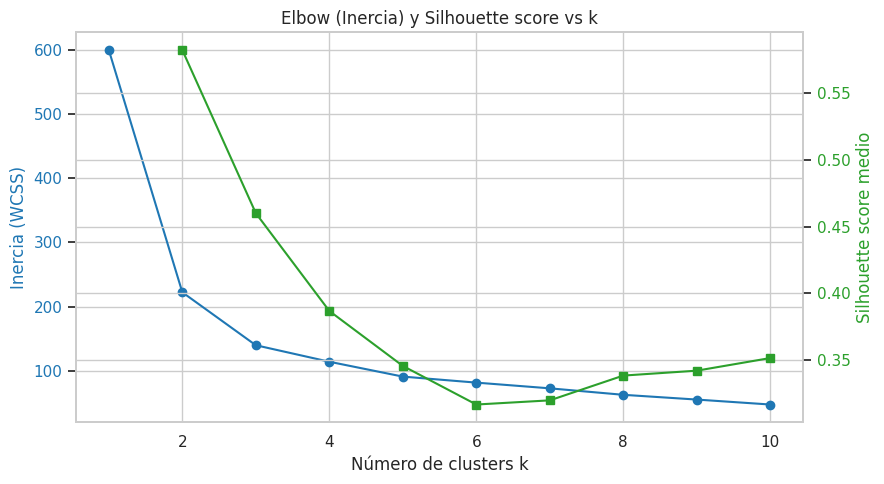

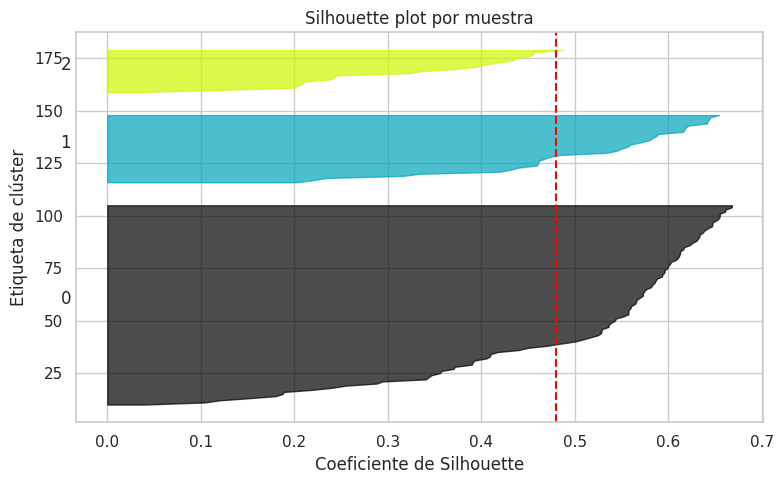

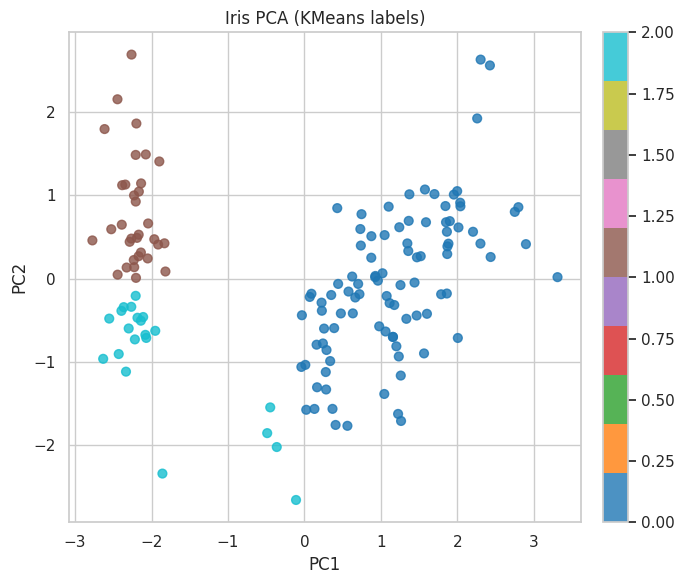

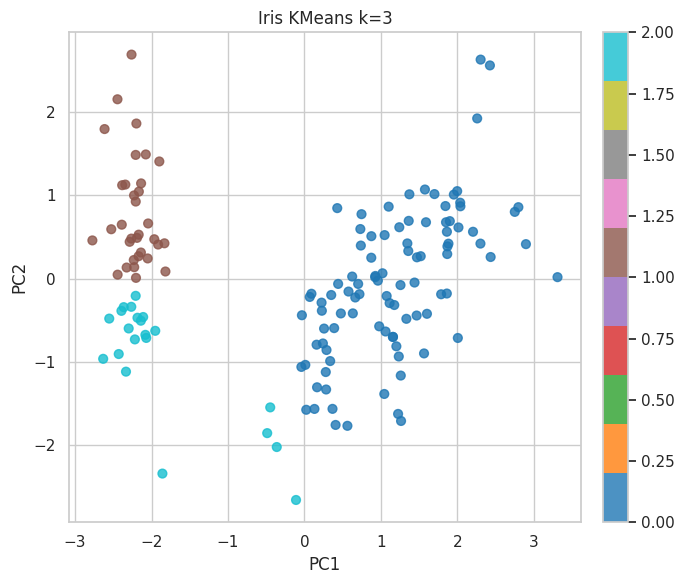

Ejercicio A completado: figuras guardadas en 'figures/'.


In [181]:
# %%
# Ejercicio A: Iris — KMeans, Elbow, Silhouette, PCA
X = X_iris_s
Ks, sse, sil = plot_elbow_silhouette(X, range(1,11), save_path_prefix='figures/elbow_and_silhouette')
# Elegir k según la curva; aquí mostramos cómo entrenar con k=3 (ajustar si corresponde)
k_chosen = 3
km = KMeans(n_clusters=k_chosen, random_state=RND).fit(X)
plot_silhouette_samples(X, km.labels_, k_chosen, filename='figures/silhouette_plot.png')
plot_pca_scatter(X, km.labels_, filename='figures/pca_projection.png', title='Iris PCA (KMeans labels)')
plot_pca_scatter(X, km.labels_, filename='figures/kmeans_clusters.png', title=f'Iris KMeans k={k_chosen}')
print("Ejercicio A completado: figuras guardadas en 'figures/'.")


Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

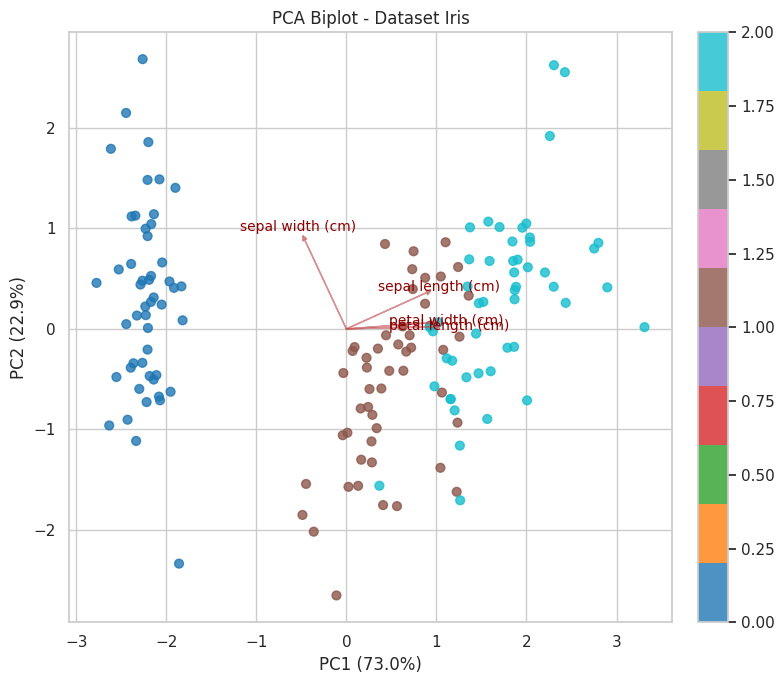

In [182]:
# Aplicar plot_pca_biplot al dataset de Iris
plot_pca_biplot(
    X=X_iris,
    labels=y_iris,
    feature_names=iris.feature_names,
    filename='figures/pca_biplot_iris.png',
    title='PCA Biplot - Dataset Iris'
)

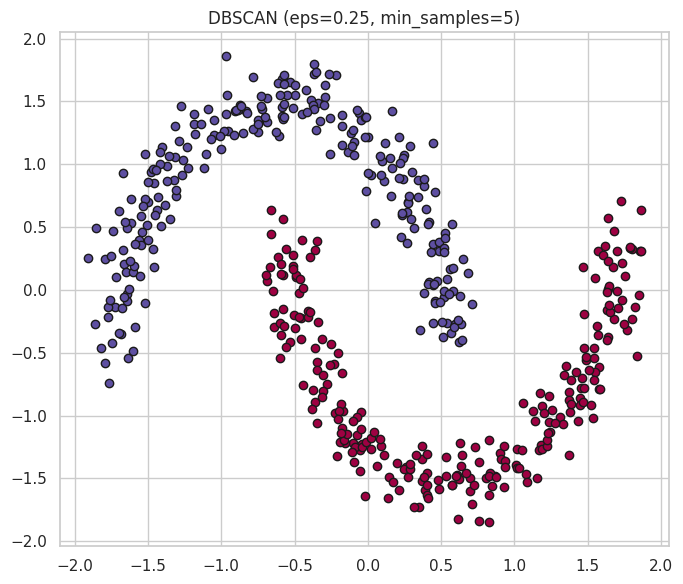

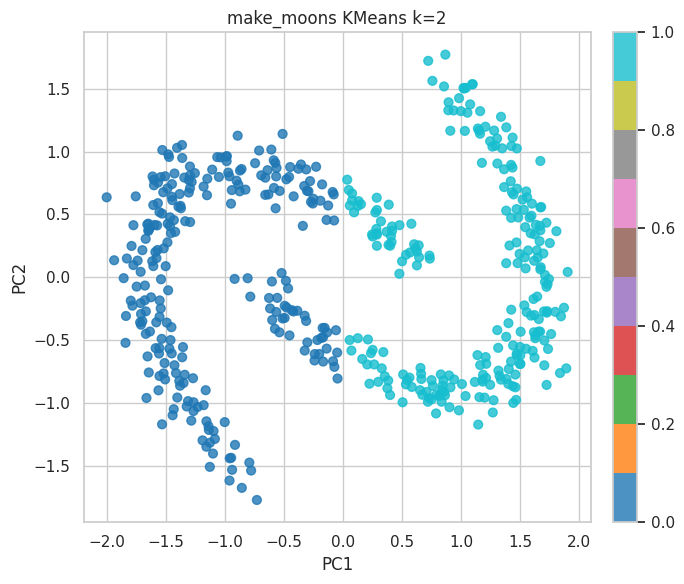

Ejercicio B completado: figuras guardadas en 'figures/'.


In [183]:
# Ejercicio B: make_moons — DBSCAN y KMeans
X = X_moons_s
plot_dbscan(X, eps=0.25, min_samples=5, filename='figures/dbscan_clusters.png')
km = KMeans(n_clusters=2, random_state=RND).fit(X)
plot_pca_scatter(X, km.labels_, filename='figures/kmeans_moons.png', title='make_moons KMeans k=2')
print("Ejercicio B completado: figuras guardadas en 'figures/'.")


Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

Ejercicio C completado: figuras gmm_covariances_*.png guardadas.


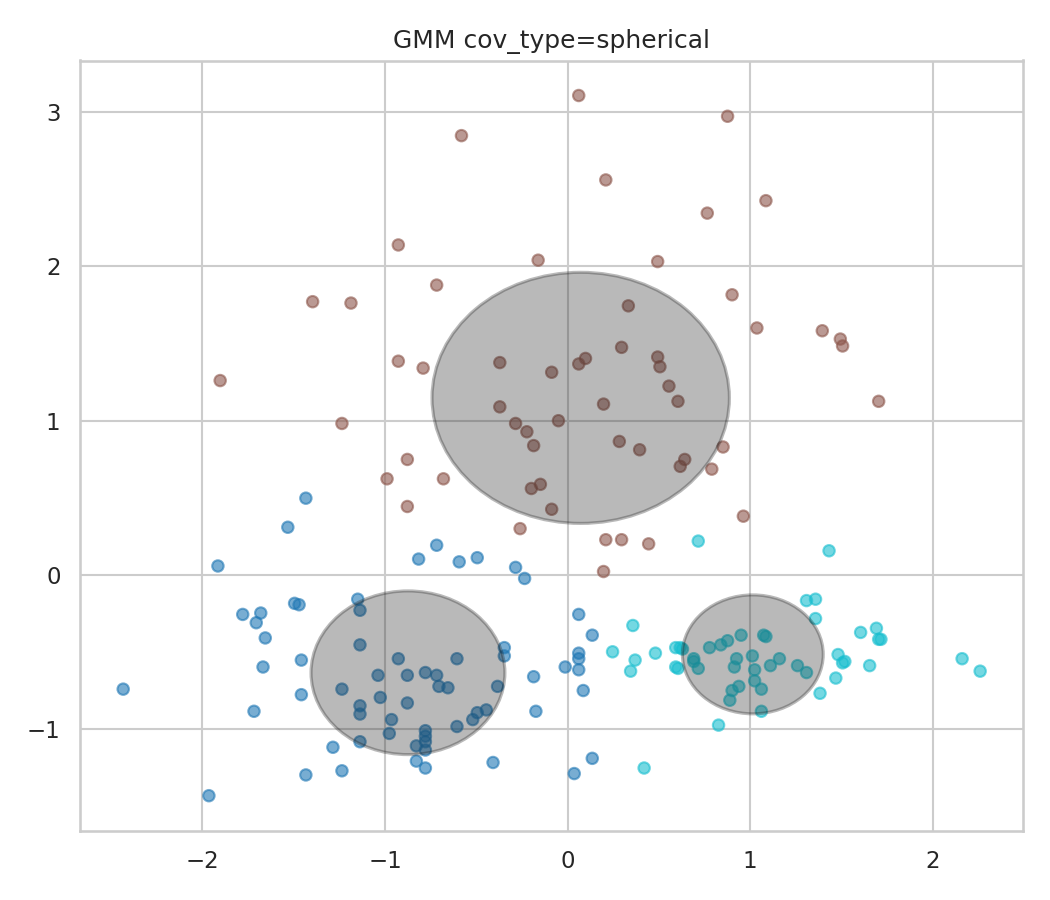

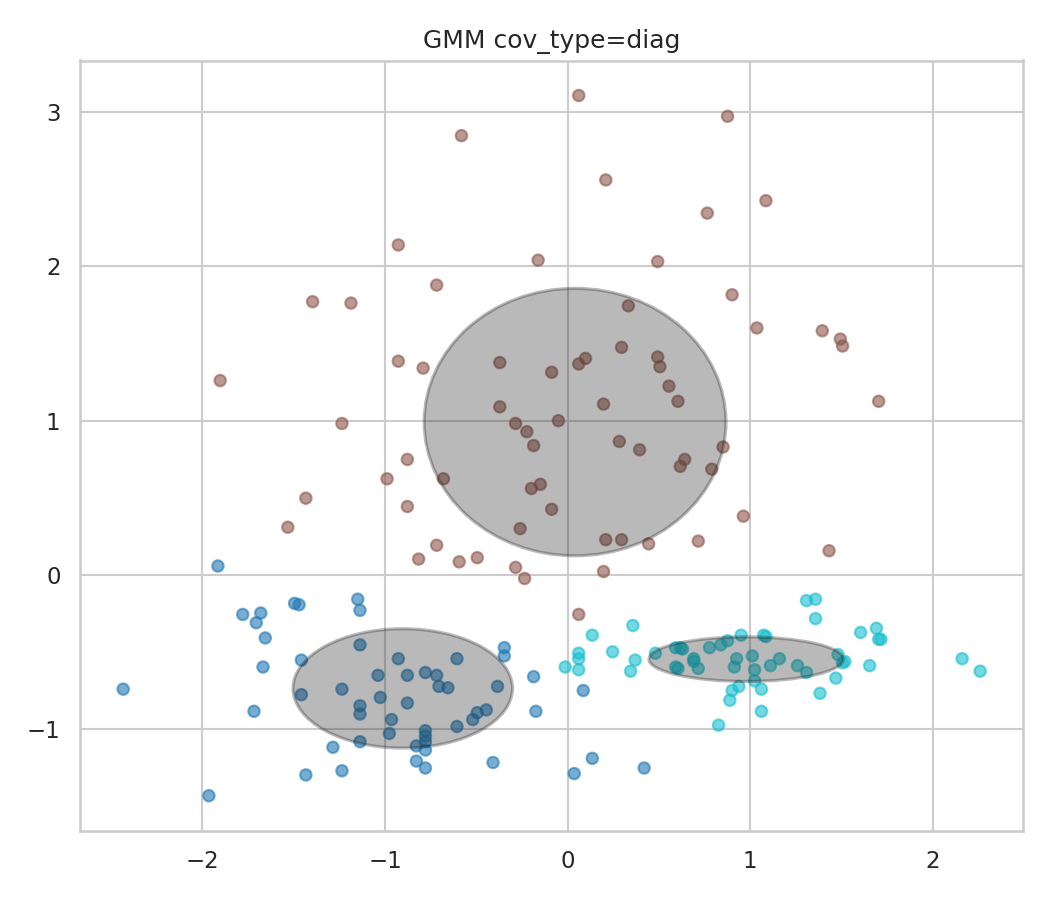

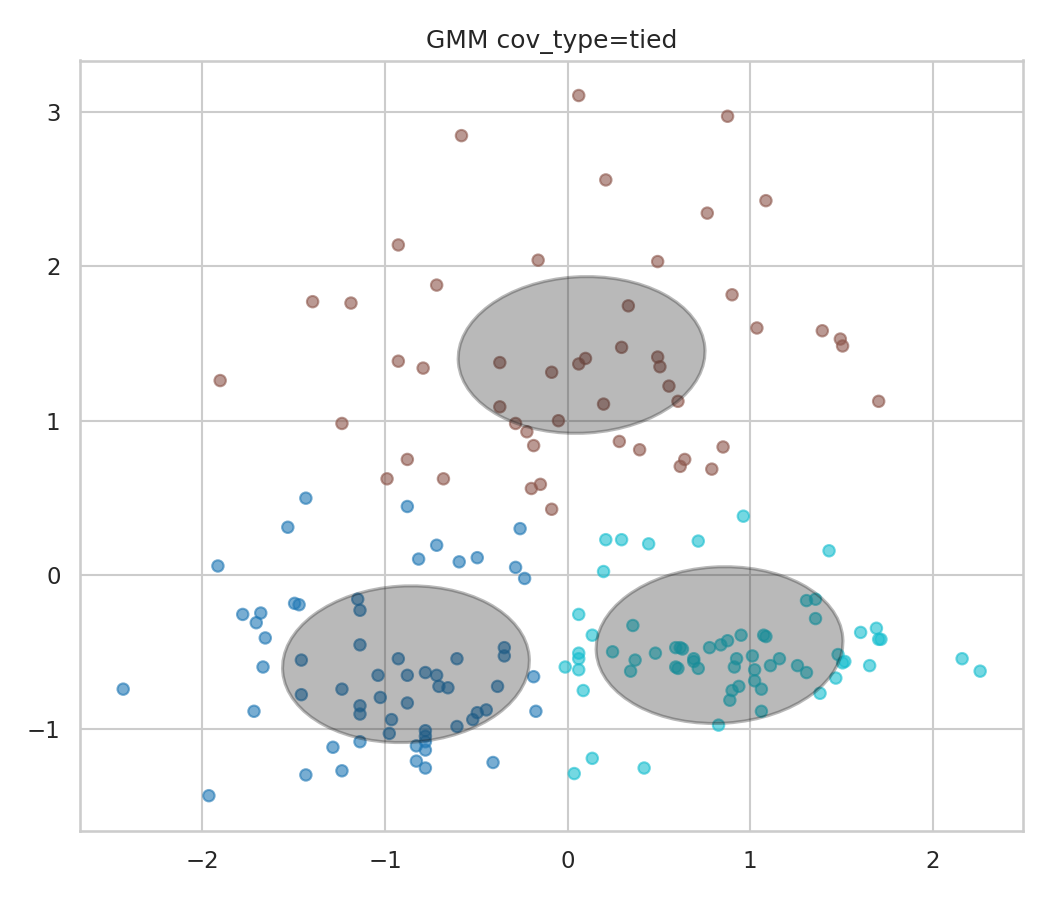

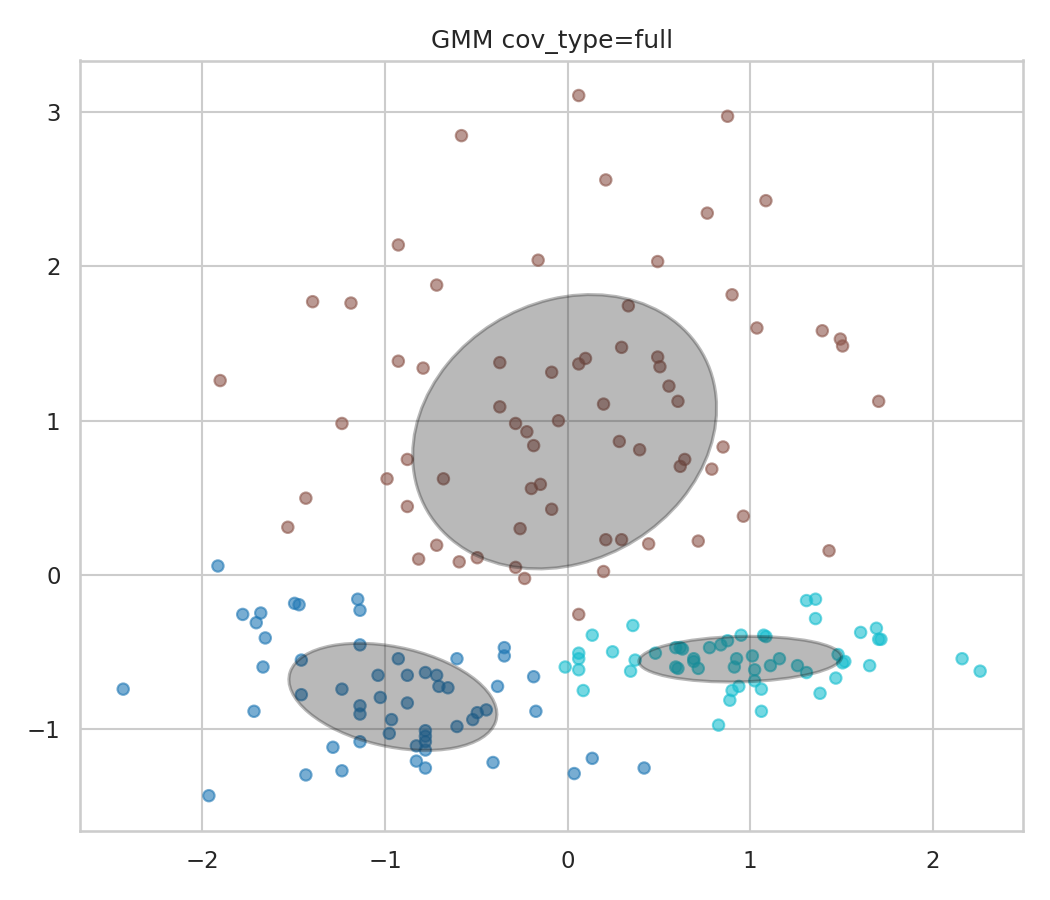

In [184]:
# %%
# Ejercicio C: GMM en Wine (usar primeras 2 features escaladas para visualización)
from IPython.display import Image, display

X = X_wine_s[:, :2]
cov_types = ['spherical','diag','tied','full']
plot_gmm_covariances(X, n_components=3, cov_types=cov_types, filename_prefix='figures/gmm_covariances')
print("Ejercicio C completado: figuras gmm_covariances_*.png guardadas.")

for cov in cov_types:
    display(Image(filename=f'figures/gmm_covariances_{cov}.png'))

Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

In [185]:
import pandas as pd

cov_types = ['spherical', 'diag', 'tied', 'full']
resultados_gmm = []

# Evaluamos cada tipo de covarianza usando el dataset Wine escalado
for cov in cov_types:
    gmm = GaussianMixture(n_components=3, covariance_type=cov, random_state=RND)
    gmm.fit(X_wine_s)
    resultados_gmm.append({
        'Covariance Type': cov,
        'BIC': gmm.bic(X_wine_s),
        'AIC': gmm.aic(X_wine_s)
    })

df_gmm_comp = pd.DataFrame(resultados_gmm)
print("Comparación de modelos GMM según tipo de covarianza (Dataset Wine, k=3):")
display(df_gmm_comp)

# Identificamos el mejor modelo según BIC (el valor más bajo es mejor)
mejor_modelo = df_gmm_comp.loc[df_gmm_comp['BIC'].idxmin()]
print(f"\nEl mejor modelo según BIC es '{mejor_modelo['Covariance Type']}' con un valor de {mejor_modelo['BIC']:.2f}")


Comparación de modelos GMM según tipo de covarianza (Dataset Wine, k=3):


,Covariance Type,BIC,AIC
0,spherical,5708.771425,5568.772949
1,diag,5556.833340,5302.290656
2,tied,5572.566078,5152.570650
3,full,5842.330292,4843.250257



El mejor modelo según BIC es 'diag' con un valor de 5556.83


### Outlier Univariado

Datos originales: [10  4  6  8  9  8  7  6 12 14 11  9  8  4  5 10 14 12 15  7 10 14 24 28]

Atípicos (Z-score a=2): [24 28] (índices: [22 23])
Atípicos (MAD a=2): [24 28] (índices: [22 23])
Atípicos (IQR c=1.5): [24 28] (índices: [22 23])


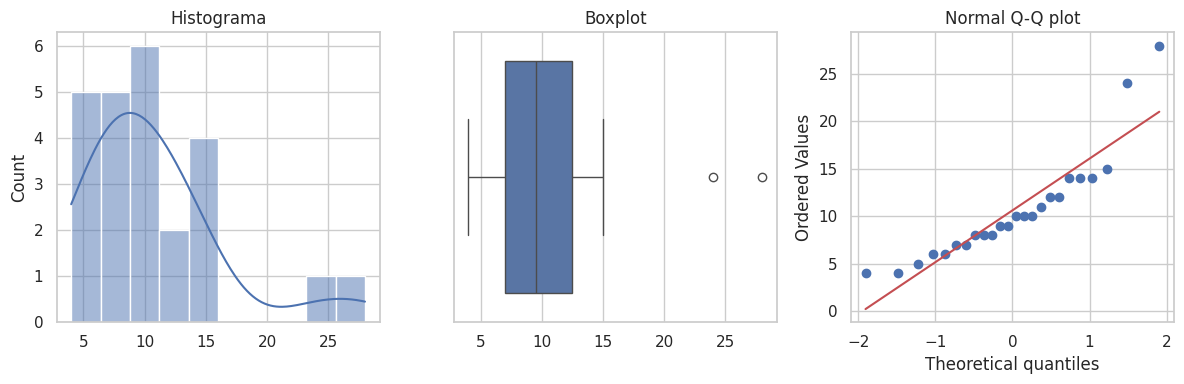

In [186]:


# --- Outlier Univariado---
x = np.array([10,4,6,8,9,8,7,6,12,14,11,9,8,4,5,10,14,12,15,7,10,14,24,28])

print("Datos originales:", x)

# 1. Usando Media y Desviación Estándar (zscore)
out_z, idx_z = detectar_outliers_univariados(x, method='zscore', threshold=2)
print(f"\nAtípicos (Z-score a=2): {out_z} (índices: {idx_z})")

# 2. Usando Mediana y MAD
out_mad, idx_mad = detectar_outliers_univariados(x, method='mad', threshold=2)
print(f"Atípicos (MAD a=2): {out_mad} (índices: {idx_mad})")

# 3. Usando Rango Intercuartílico (IQR)
out_iqr, idx_iqr = detectar_outliers_univariados(x, method='iqr', threshold=1.5)
print(f"Atípicos (IQR c=1.5): {out_iqr} (índices: {idx_iqr})")

# Visualización de los atípicos encontrados con IQR
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.histplot(x, bins=10, kde=True)
plt.title("Histograma")

plt.subplot(1, 3, 2)
sns.boxplot(x=x)
# Marcar los atípicos del IQR en el boxplot (Seaborn ya los muestra por defecto,
# pero esto es para ver que coinciden)
plt.title("Boxplot")

plt.subplot(1, 3, 3)
stats.probplot(x, dist="norm", plot=plt)
plt.title("Normal Q-Q plot")

plt.tight_layout()
plt.show()

Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

In [187]:
import numpy as np
from outliers import smirnov_grubbs as grubbs
import pandas as pd

# --- 1. Prueba de Grubbs ---
print("--- Prueba de Grubbs ---")
x_grubbs = np.array([10,4,6,8,9,8,7,6,12,14,11,9,8,4,5,10,14,12,15,7,10,14])

# La función max_test de smirnov_grubbs busca valores atípicos en el extremo superior
# y min_test en el extremo inferior.
# test() busca en ambos lados y retorna el array sin los outliers.

outliers_grubbs = grubbs.test(x_grubbs, alpha=0.05)
print("Datos originales:", x_grubbs)
print("Datos sin outliers (Grubbs):", outliers_grubbs)

# --- 2. Test Q de Dixon ---
# Implementación manual básica para Dixon Q-test (valida para N entre 3 y 29)
def dixon_q_test(data, left=True, right=True, q_dict=None):
    """
    Aplica el Test Q de Dixon para detectar un outlier en un conjunto pequeño de datos.
    """
    # Valores críticos de Q para alpha=0.05 (N de 3 a 29)
    if q_dict is None:
        q_dict = {3: 0.97, 4: 0.829, 5: 0.71, 6: 0.625, 7: 0.568, 8: 0.526, 9: 0.493,
                  10: 0.466, 11: 0.444, 12: 0.426, 13: 0.41, 14: 0.396, 15: 0.384,
                  16: 0.374, 17: 0.365, 18: 0.356, 19: 0.349, 20: 0.342, 21: 0.337,
                  22: 0.331, 23: 0.326, 24: 0.321, 25: 0.317, 26: 0.312, 27: 0.308,
                  28: 0.305, 29: 0.301}

    sdata = np.sort(data)
    n = len(sdata)
    if n not in q_dict:
        print("El tamaño de la muestra debe estar entre 3 y 29 para esta tabla de Dixon.")
        return []

    outliers = []
    q_crit = q_dict[n]

    # Test para el valor mínimo
    if left:
        q_min = (sdata[1] - sdata[0]) / (sdata[-1] - sdata[0])
        if q_min > q_crit:
            outliers.append(sdata[0])

    # Test para el valor máximo
    if right:
        q_max = (sdata[-1] - sdata[-2]) / (sdata[-1] - sdata[0])
        if q_max > q_crit:
            outliers.append(sdata[-1])

    return outliers

print("\n--- Test Q de Dixon ---")
y_dixon = np.array([-10,10,4,6,8,9,8,7,6,12,14,11,9,8,4,5,10,14,12,15,7,10,14])
print("Datos originales para Dixon:", y_dixon)

outliers_dixon = dixon_q_test(y_dixon)
print("Atípicos detectados (Dixon Q-test, alpha=0.05):", outliers_dixon)

--- Prueba de Grubbs ---
Datos originales: [10  4  6  8  9  8  7  6 12 14 11  9  8  4  5 10 14 12 15  7 10 14]
Datos sin outliers (Grubbs): [10  4  6  8  9  8  7  6 12 14 11  9  8  4  5 10 14 12 15  7 10 14]

--- Test Q de Dixon ---
Datos originales para Dixon: [-10  10   4   6   8   9   8   7   6  12  14  11   9   8   4   5  10  14
  12  15   7  10  14]
Atípicos detectados (Dixon Q-test, alpha=0.05): [np.int64(-10)]


Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

Visualizando outliers detectados por IQR:


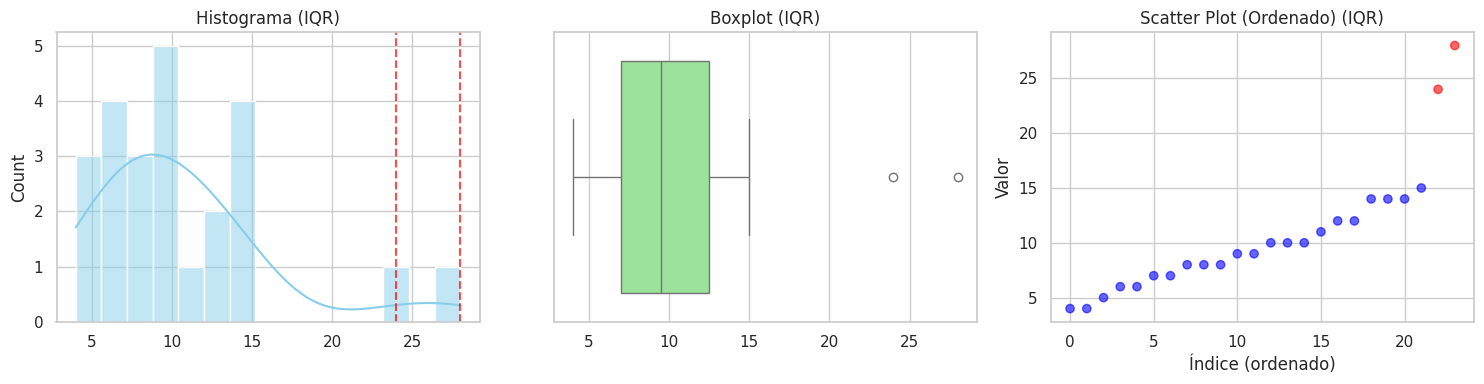


Visualizando outliers detectados por Dixon Q-test:


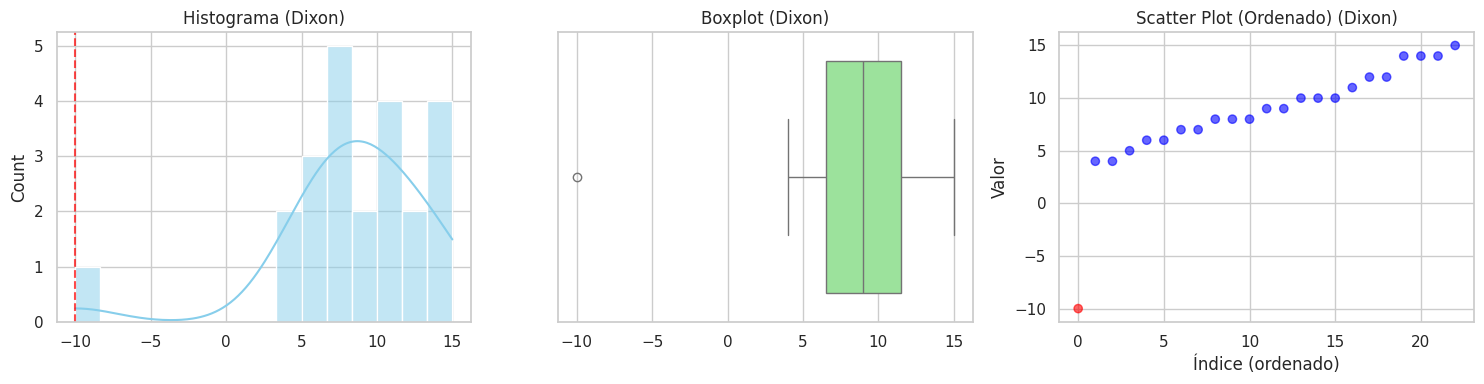

In [188]:
# Ejemplo de uso con los resultados anteriores de IQR
print("Visualizando outliers detectados por IQR:")
plot_outliers(x, out_iqr, title_suffix='(IQR)')

# Ejemplo de uso con los resultados de Dixon
print("\nVisualizando outliers detectados por Dixon Q-test:")
plot_outliers(y_dixon, outliers_dixon, title_suffix='(Dixon)')

Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

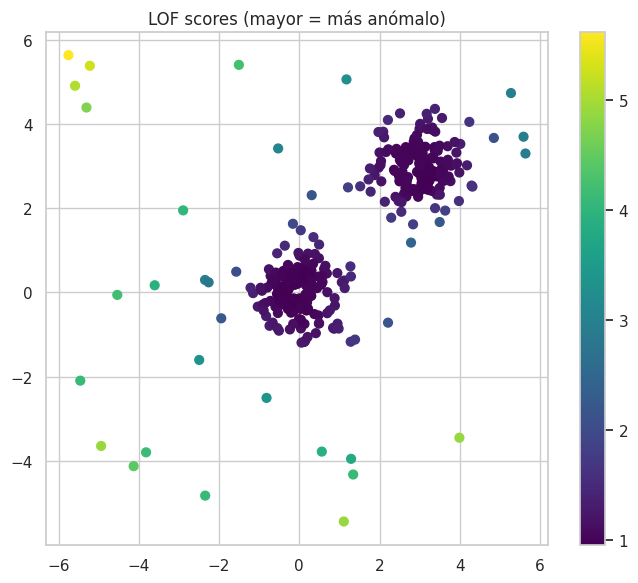

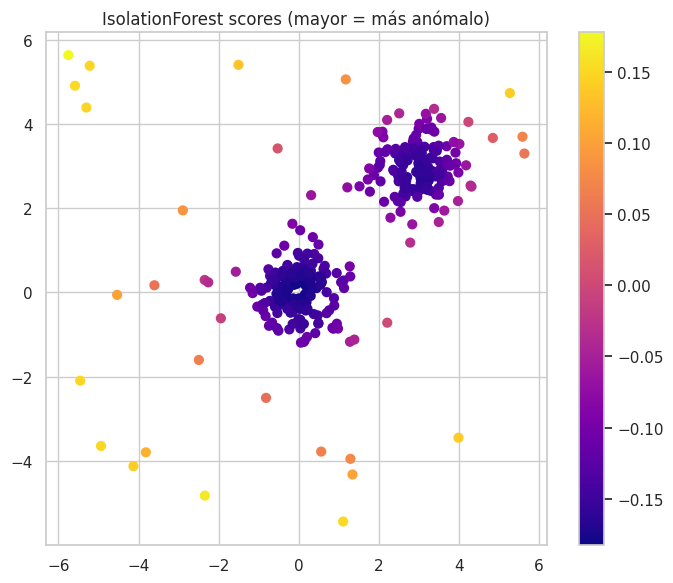

Ejercicio D completado: figuras outliers_lof.png y outliers_isolationforest.png guardadas.


In [189]:
# %%
# Ejercicio D: Detección de anomalías — LOF y IsolationForest en datos sintéticos
X_inliers, _ = make_blobs(n_samples=300, centers=[[0,0],[3,3]], cluster_std=0.6, random_state=RND)
rng = np.random.RandomState(RND)
X_outliers = rng.uniform(low=-6, high=6, size=(30,2))
X_mixed = np.vstack([X_inliers, X_outliers])
plot_lof(X_mixed, n_neighbors=20, contamination=0.08, filename='figures/outliers_lof.png')
plot_isolation_forest(X_mixed, contamination=0.08, filename='figures/outliers_isolationforest.png')
print("Ejercicio D completado: figuras outliers_lof.png y outliers_isolationforest.png guardadas.")


Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

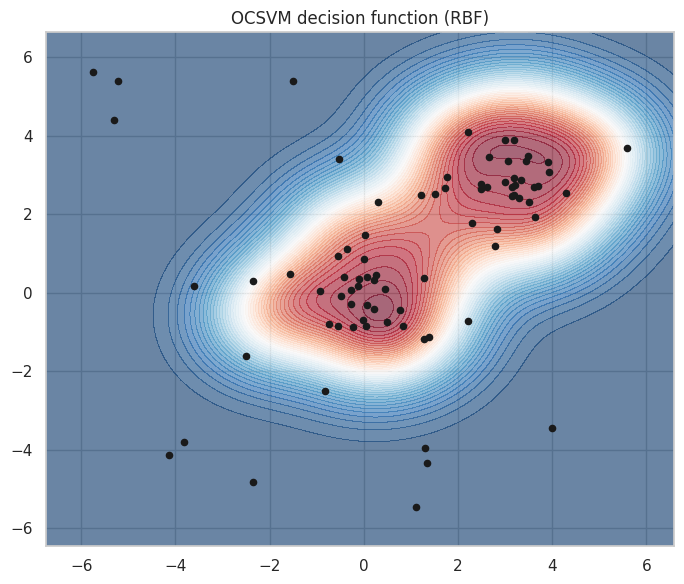

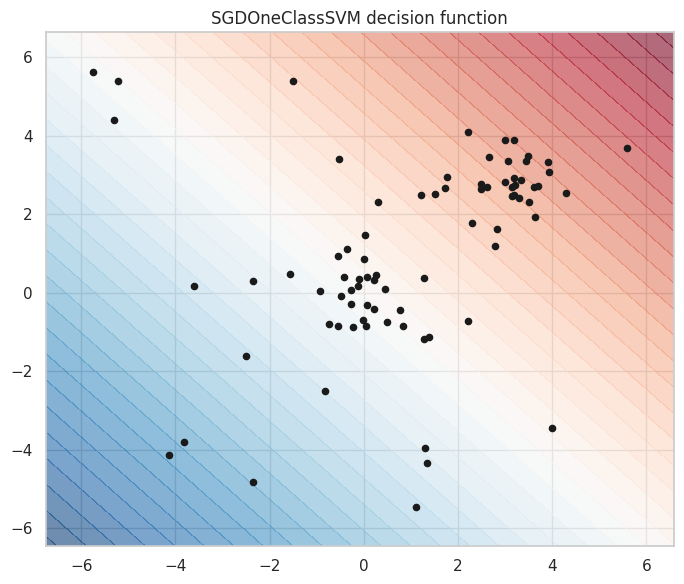

Ejercicio E completado: figuras ocsvm_vs_sgd_ocsvm.png y ocsvm_vs_sgd_sgd.png guardadas.


In [190]:
# %%
# Ejercicio E: Comparación OCSVM vs SGD en dataset sintético (2D)
from sklearn.linear_model import SGDOneClassSVM

def compare_ocsvm_sgd_fixed(X_train, X_test, filename_prefix='figures/ocsvm_vs_sgd'):
    ocsvm = OneClassSVM(kernel='rbf', gamma=0.5, nu=0.05)
    ocsvm.fit(X_train)

    # Usamos SGDOneClassSVM, que está diseñado para entrenarse con una sola clase
    sgd = SGDOneClassSVM(nu=0.05, random_state=RND)
    sgd.fit(X_train)

    # Malla para contornos
    x_min, x_max = X_test[:,0].min()-1, X_test[:,0].max()+1
    y_min, y_max = X_test[:,1].min()-1, X_test[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # OCSVM decision
    Z1 = ocsvm.decision_function(grid).reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(7,6))
    ax.contourf(xx, yy, Z1, levels=50, cmap='RdBu_r', alpha=0.6)
    ax.scatter(X_test[:,0], X_test[:,1], c='k', s=20)
    ax.set_title('OCSVM decision function (RBF)')
    plt.tight_layout()
    fig.savefig(f'{filename_prefix}_ocsvm.png', dpi=150)
    plt.show()
    plt.close(fig)

    # SGD decision
    Z2 = sgd.decision_function(grid).reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(7,6))
    ax.contourf(xx, yy, Z2, levels=50, cmap='RdBu_r', alpha=0.6)
    ax.scatter(X_test[:,0], X_test[:,1], c='k', s=20)
    ax.set_title('SGDOneClassSVM decision function')
    plt.tight_layout()
    fig.savefig(f'{filename_prefix}_sgd.png', dpi=150)
    plt.show()
    plt.close(fig)

X_train, X_test = train_test_split(X_inliers, test_size=0.2, random_state=RND)
X_test_full = np.vstack([X_test, X_outliers[:20]])
compare_ocsvm_sgd_fixed(X_train, X_test_full, filename_prefix='figures/ocsvm_vs_sgd')
print("Ejercicio E completado: figuras ocsvm_vs_sgd_ocsvm.png y ocsvm_vs_sgd_sgd.png guardadas.")

Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

# 5) **Evaluación y métricas**
# Calculamos silhouette_score, inertia para KMeans (Iris) y BIC/AIC para GMM (Wine).
# Guardamos un resumen en 'cluster_summary.csv'.


In [191]:
# %%
summary = []
# Iris KMeans k=3
km = KMeans(n_clusters=3, random_state=RND).fit(X_iris_s)
summary.append({
    'dataset':'Iris','method':'KMeans','k':3,
    'inertia': float(km.inertia_),
    'silhouette': float(silhouette_score(X_iris_s, km.labels_))
})
# Wine GMM (full) with 3 components (usar X_wine_s completo)
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=RND).fit(X_wine_s)
summary.append({
    'dataset':'Wine','method':'GMM_full','k':3,
    'bic': float(gmm.bic(X_wine_s)),
    'aic': float(gmm.aic(X_wine_s))
})
# DBSCAN on moons (example)
db = DBSCAN(eps=0.25, min_samples=5).fit(X_moons_s)
labels_db = db.labels_
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
summary.append({
    'dataset':'moons','method':'DBSCAN','n_clusters': n_clusters_db,
    'noise_points': int((labels_db==-1).sum())
})
df_summary = pd.DataFrame(summary)
df_summary.to_csv('cluster_summary.csv', index=False)
df_summary


,dataset,method,k,inertia,silhouette,bic,aic,n_clusters,noise_points
0,Iris,KMeans,3.0,191.024737,0.479881,NaN,NaN,NaN,NaN
1,Wine,GMM_full,3.0,NaN,NaN,5842.330292,4843.250257,NaN,NaN
2,moons,DBSCAN,NaN,NaN,NaN,NaN,NaN,2.0,0.0


Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:


# 6) **Widgets interactivos (selección de dataset y controles)**
# Widgets para ajustar parámetros y ejecutar las funciones utilitarias.


In [192]:
# %%
# Variables globales que usarán los widgets
X_current = X_iris_s
X_2d_current = X_iris_s[:, :2]
X_train_2d, X_test_2d = train_test_split(X_2d_current, test_size=0.3, random_state=RND)

# Selector de dataset
dataset_dropdown = widgets.Dropdown(
    options=[('Iris','iris'), ('Wine','wine'), ('Moons','moons'), ('Circles','circles'), ('Digits (sub)','digits')],
    value='iris', description='Dataset:')
out_dataset = widgets.Output()

def on_dataset_change(change):
    global X_current, X_2d_current, X_train_2d, X_test_2d
    with out_dataset:
        clear_output(wait=True)
        name = change['new']
        if name == 'iris':
            X_current = X_iris_s
            X_2d_current = X_iris_s[:,:2]
            print('Dataset seleccionado: Iris (escalado)')
        elif name == 'wine':
            X_current = X_wine_s
            X_2d_current = X_wine_s[:,:2]
            print('Dataset seleccionado: Wine (escalado)')
        elif name == 'moons':
            X_current = X_moons_s
            X_2d_current = X_moons_s
            print('Dataset seleccionado: Moons (escalado)')
        elif name == 'circles':
            X_current = X_circles_s
            X_2d_current = X_circles_s
            print('Dataset seleccionado: Circles (escalado)')
        elif name == 'digits':
            X_current = X_digits_s
            X_2d_current = X_digits_s[:,:2]
            print('Dataset seleccionado: Digits (submuestra, escalado)')
        # Preparar datos 2D para OCSVM vs SGD (train/test)
        if X_2d_current.shape[1] >= 2:
            X_train_2d, X_test_2d = train_test_split(X_2d_current, test_size=0.3, random_state=RND)
        else:
            X_train_2d = X_test_2d = X_2d_current

dataset_dropdown.observe(on_dataset_change, names='value')
display(dataset_dropdown, out_dataset)
on_dataset_change({'new': dataset_dropdown.value})


Dropdown(description='Dataset:', options=(('Iris', 'iris'), ('Wine', 'wine'), ('Moons', 'moons'), ('Circles', …

Output()

Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

In [193]:
# %%
# Widget: Elbow + Silhouette interactivo
from IPython.display import Image, display

k_min = widgets.IntSlider(value=1, min=1, max=10, step=1, description='k min:')
k_max = widgets.IntSlider(value=8, min=2, max=20, step=1, description='k max:')
run_elbow = widgets.Button(description='Generar Elbow+Silhouette', button_style='primary')
out_elbow = widgets.Output()

def on_run_elbow(b):
    with out_elbow:
        clear_output(wait=True)
        km_range = range(k_min.value, k_max.value+1)
        Ks, sse, sil = plot_elbow_silhouette(X_current, km_range, save_path_prefix='figures/elbow_and_silhouette')
        print('Figura guardada: figures/elbow_and_silhouette.png')
        display(Image(filename='figures/elbow_and_silhouette.png'))

run_elbow.on_click(on_run_elbow)
display(widgets.HBox([k_min, k_max, run_elbow]), out_elbow)


Output()

Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

In [194]:
# %%
# Widget: elegir k y generar Silhouette + PCA
from IPython.display import Image, display

k_choose = widgets.IntSlider(value=3, min=2, max=10, step=1, description='k:')
run_k_visual = widgets.Button(description='Generar Silhouette + PCA', button_style='info')
out_k_visual = widgets.Output()

def on_run_k_visual(b):
    with out_k_visual:
        clear_output(wait=True)
        k = k_choose.value
        km = KMeans(n_clusters=k, random_state=RND).fit(X_current)
        plot_silhouette_samples(X_current, km.labels_, k, filename='figures/silhouette_plot.png')
        plot_pca_scatter(X_current, km.labels_, filename='figures/pca_projection.png', title=f'PCA (K={k})')
        plot_pca_scatter(X_current, km.labels_, filename='figures/kmeans_clusters.png', title=f'KMeans k={k}')
        print('Figuras guardadas: silhouette_plot.png, pca_projection.png, kmeans_clusters.png')
        display(Image(filename='figures/silhouette_plot.png'))
        display(Image(filename='figures/pca_projection.png'))
        display(Image(filename='figures/kmeans_clusters.png'))

run_k_visual.on_click(on_run_k_visual)
display(widgets.HBox([k_choose, run_k_visual]), out_k_visual)


Output()

Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

In [195]:
# %%
# Widget: DBSCAN interactivo
from IPython.display import Image, display

eps_slider = widgets.FloatSlider(value=0.3, min=0.01, max=1.5, step=0.01, description='eps:')
min_samples_slider = widgets.IntSlider(value=5, min=1, max=50, step=1, description='minPts:')
run_dbscan = widgets.Button(description='Ejecutar DBSCAN', button_style='warning')
out_dbscan = widgets.Output()

def on_run_dbscan(b):
    with out_dbscan:
        clear_output(wait=True)
        plot_dbscan(X_current, eps=eps_slider.value, min_samples=min_samples_slider.value, filename='figures/dbscan_clusters.png')
        print(f'Figura guardada: figures/dbscan_clusters.png (eps={eps_slider.value}, min_samples={min_samples_slider.value})')
        display(Image(filename='figures/dbscan_clusters.png'))

run_dbscan.on_click(on_run_dbscan)
display(widgets.HBox([eps_slider, min_samples_slider, run_dbscan]), out_dbscan)


Output()

Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

In [196]:
# %%
# Widget: LOF interactivo
from IPython.display import Image, display

n_neighbors_w = widgets.IntSlider(value=20, min=5, max=100, step=1, description='n_neighbors:')
contamination_w = widgets.FloatSlider(value=0.05, min=0.0, max=0.5, step=0.01, description='contamination:')
run_lof = widgets.Button(description='Ejecutar LOF', button_style='danger')
out_lof = widgets.Output()

def on_run_lof(b):
    with out_lof:
        clear_output(wait=True)
        scores = plot_lof(X_current, n_neighbors=n_neighbors_w.value, contamination=contamination_w.value, filename='figures/outliers_lof.png')
        print('Figura guardada: figures/outliers_lof.png')
        idx_top = scores.argsort()[::-1][:5]
        print('Top 5 índices más anómalos (según LOF):', idx_top)
        display(Image(filename='figures/outliers_lof.png'))

run_lof.on_click(on_run_lof)
display(widgets.HBox([n_neighbors_w, contamination_w, run_lof]), out_lof)


Output()

Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

In [197]:
# %%
# Widget: GMM interactivo (usar X_2d_current para visualización)
from IPython.display import Image, display

cov_dropdown = widgets.Dropdown(options=['spherical','diag','tied','full'], value='full', description='cov_type:')
ncomp_slider = widgets.IntSlider(value=3, min=1, max=8, step=1, description='n_components:')
run_gmm = widgets.Button(description='Ajustar GMM', button_style='success')
out_gmm = widgets.Output()

def on_run_gmm(b):
    with out_gmm:
        clear_output(wait=True)
        try:
            plot_gmm_covariances(X_2d_current, n_components=ncomp_slider.value, cov_types=[cov_dropdown.value], filename_prefix='figures/gmm_covariances')
            print(f'Figura guardada: figures/gmm_covariances_{cov_dropdown.value}.png')
            display(Image(filename=f'figures/gmm_covariances_{cov_dropdown.value}.png'))
        except Exception as e:
            print('Error: para trazar covarianzas la matriz X debe ser 2D (dos columnas).', e)

run_gmm.on_click(on_run_gmm)
display(widgets.HBox([cov_dropdown, ncomp_slider, run_gmm]), out_gmm)


Output()

Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

In [198]:
# %%
# Widget: OCSVM vs SGD interactivo (usa X_train_2d y X_test_2d)
from IPython.display import Image, display
import ipywidgets as widgets
from IPython.display import clear_output

nu_w = widgets.FloatSlider(value=0.05, min=0.001, max=0.5, step=0.01, description='nu:')
gamma_w = widgets.FloatLogSlider(value=0.5, base=10, min=-3, max=1, step=0.1, description='gamma:')
run_ocsvm = widgets.Button(description='Comparar OCSVM vs SGD', button_style='primary')
out_ocsvm = widgets.Output()

def on_run_ocsvm(b):
    with out_ocsvm:
        clear_output(wait=True)
        try:
            # Usamos compare_ocsvm_sgd_fixed para evitar el error de 1 clase con SGDClassifier
            compare_ocsvm_sgd_fixed(X_train_2d, X_test_2d, filename_prefix='figures/ocsvm_vs_sgd')
            print('Figuras guardadas: figures/ocsvm_vs_sgd_ocsvm.png, figures/ocsvm_vs_sgd_sgd.png')
            display(Image(filename='figures/ocsvm_vs_sgd_ocsvm.png'))
            display(Image(filename='figures/ocsvm_vs_sgd_sgd.png'))
        except Exception as e:
            print('Error: asegúrate de tener X_train_2d y X_test_2d con 2 columnas para trazar contornos.', e)

run_ocsvm.on_click(on_run_ocsvm)
display(widgets.HBox([nu_w, gamma_w, run_ocsvm]), out_ocsvm)


Output()

Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

In [199]:
# %%
# Botón para listar archivos generados (resumen)
list_files_btn = widgets.Button(description='Listar archivos generados', button_style='')
out_files = widgets.Output()

def on_list_files(b):
    with out_files:
        clear_output(wait=True)
        import glob
        files = sorted(glob.glob('figures/*') + glob.glob('*.csv'))
        if not files:
            print('No se han generado archivos aún.')
        else:
            for f in files:
                print('-', f)

list_files_btn.on_click(on_list_files)
display(list_files_btn, out_files)


Button(description='Listar archivos generados', style=ButtonStyle())

Output()

Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:


# 7) **Nota docente y checklist de entrega**
# - Escalar siempre antes de KMeans/DBSCAN/OCSVM.
# - Usar kmeans++ y múltiples reinicios (n_init) para KMeans.
# - Regularizar covarianzas en GMM si aparecen matrices singulares.
# - Para Silhouette en datasets grandes, usar muestreo.
#
# Checklist de archivos (deben existir en 'figures/' o en el directorio):
# pca_projection.png
# kmeans_clusters.png
# elbow_and_silhouette.png
# silhouette_plot.png
# dbscan_clusters.png
# kmeans_moons.png
# gmm_covariances_spherical.png
# gmm_covariances_diag.png
# gmm_covariances_tied.png
# gmm_covariances_full.png
# outliers_lof.png
# outliers_isolationforest.png
# ocsvm_vs_sgd_ocsvm.png
# ocsvm_vs_sgd_sgd.png
# cluster_summary.csv


In [200]:
# %%
# 8) Resumen final: listar y confirmar existencia de archivos generados
import glob
files = sorted(glob.glob('figures/*') + glob.glob('*.csv'))
print("Archivos generados:")
for f in files:
    print("-", f)

# (Opcional en Colab) empaquetar figuras y CSV en zip para descargar:
# !zip -r figures_and_summary.zip figures/ cluster_summary.csv
# Luego usar: from google.colab import files; files.download('figures_and_summary.zip')


Archivos generados:
- cluster_summary.csv
- figures/dbscan_clusters.png
- figures/elbow_and_silhouette.png
- figures/gmm_covariances_diag.png
- figures/gmm_covariances_full.png
- figures/gmm_covariances_spherical.png
- figures/gmm_covariances_tied.png
- figures/kmeans_clusters.png
- figures/kmeans_moons.png
- figures/ocsvm_vs_sgd_ocsvm.png
- figures/ocsvm_vs_sgd_sgd.png
- figures/outliers_isolationforest.png
- figures/outliers_lof.png
- figures/pca_biplot_iris.png
- figures/pca_projection.png
- figures/silhouette_plot.png


Tarea - Comenta que taréa se implmentó en la celda anterior y los resultados obtenidos:

#### Desafío 1 — KMeans y selección de \(K\)

**Objetivo**  
Elegir el número de clústeres más adecuado para el dataset *Iris* combinando Elbow y Silhouette.

**Pasos sugeridos**
1. Escalar los datos con `StandardScaler`.
2. Ejecutar `plot_elbow_silhouette(X_iris_s, range(1,11))`.
3. Identificar rango candidato con Elbow y calcular Silhouette medio dentro del rango.
4. Entrenar `KMeans` con el \(k\) elegido (usar `n_init>=10`) y generar `silhouette_plot.png` y `pca_projection.png`.
5. Repetir KMeans con 3 semillas distintas y comparar inercia.

**Entregables**
- `elbow_and_silhouette.png`  
- `silhouette_plot.png`  
- `pca_projection.png`  
- Justificación escrita (3–5 líneas) del \(k\) elegido.

**Pistas**
- Escala siempre antes de KMeans.
- Observa la estabilidad entre reinicios (`n_init` y `random_state`).

**Criterios de evaluación**
- Curvas correctas y archivos guardados; coherencia entre Elbow y Silhouette; justificación breve y reproducible.


#### Desafío 2 — Clustering no lineal y DBSCAN

**Objetivo**  
Comparar KMeans y DBSCAN en `make_moons` y explicar por qué uno funciona mejor.

**Pasos sugeridos**
1. Escalar `make_moons` con `StandardScaler`.
2. Ejecutar `KMeans(n_clusters=2)` y guardar `kmeans_moons.png`.
3. Trazar k‑dist plot para elegir `eps`, ejecutar `plot_dbscan(X_moons_s, eps, min_samples)` y guardar `dbscan_clusters.png`.
4. Analizar resultados y redactar 5–8 líneas explicando la diferencia.

**Entregables**
- `dbscan_clusters.png`  
- `kmeans_moons.png`  
- Informe corto (5–8 líneas).

**Pistas**
- DBSCAN detecta formas no convexas; KMeans asume clústeres esféricos.
- Usa k‑dist plot para seleccionar `eps`.

**Criterios de evaluación**
- Visualizaciones claras; elección razonada de `eps`; explicación técnica sobre forma y densidad.


#### Desafío 3 — GMM Covarianzas y selección por BIC

**Objetivo**  
Comparar `spherical`, `diag`, `tied`, `full` en Wine (2D) y seleccionar el mejor modelo con BIC.

**Pasos sugeridos**
1. Usar `X_wine_s[:,:2]` para visualización 2D.
2. Ejecutar `plot_gmm_covariances` con `n_components=3` y cada `cov_type`.
3. Calcular `bic` y `aic` para cada modelo.
4. Interpretar elipses y justificar la elección equilibrando ajuste y complejidad.

**Entregables**
- `gmm_covariances_spherical.png`  
- `gmm_covariances_diag.png`  
- `gmm_covariances_tied.png`  
- `gmm_covariances_full.png`  
- Tabla con BIC/AIC y elección final.

**Pistas**
- `full` tiene más parámetros; BIC penaliza complejidad.
- Observa solapamiento y orientación de elipses.

**Criterios de evaluación**
- Figuras correctas; cálculo BIC/AIC correcto; justificación técnica que considere penalización por complejidad.


#### Desafío 4 — Detección de anomalías comparativa

**Objetivo**  
Comparar LOF e IsolationForest en un dataset con outliers sintéticos y medir coincidencia en detecciones.

**Pasos sugeridos**
1. Generar `X_inliers` con `make_blobs` y `X_outliers` uniformes; combinar en `X_mixed`.
2. Ejecutar `plot_lof(X_mixed, ...)` y `plot_isolation_forest(X_mixed, ...)`.
3. Ordenar por score y comparar top‑10/top‑20 entre métodos.
4. Visualizar coincidencias en un scatter y comentar diferencias.

**Entregables**
- `outliers_lof.png`  
- `outliers_isolationforest.png`  
- Tabla con número de coincidencias en top‑10 y top‑20.

**Pistas**
- Ordena por score descendente; ajustar `contamination` para etiquetado automático.

**Criterios de evaluación**
- Figuras y métricas correctas; análisis de por qué coinciden o difieren (densidad local vs aislamiento).


#### Desafío 5 — Mini proyecto exploratorio

**Objetivo**  
Aplicar un pipeline completo a un dataset real (p. ej. subset MNIST) y presentar un informe con visualizaciones, métricas y conclusiones.

**Requisitos mínimos**
- Preprocesamiento justificado; al menos tres métodos aplicados (KMeans, GMM, DBSCAN o LOF/IsolationForest).
- Selección de \(k\) con Elbow+Silhouette o BIC.
- Visualizaciones: PCA/t‑SNE, silhouette plot, covarianzas GMM o contornos OCSVM.

**Entregables**
- Notebook ejecutable; carpeta `figures/` con figuras; informe (Markdown o PDF) 1–2 páginas.

**Pistas**
- Documenta decisiones y limitaciones.

**Criterios de evaluación**
- Calidad del análisis, reproducibilidad y claridad del informe.


### Rúbrica de evaluación — Clase 5: Aprendizaje No Supervisado
**Total: 100 puntos**

#### Criterios y pesos
| **Criterio** | **Peso (puntos)** | **Descripción (una línea)** |
|---|---:|---|
| **Correctitud técnica** | **30** | Código que ejecuta, produce resultados esperados y guarda los archivos solicitados. |
| **Interpretación y análisis** | **20** | Calidad de las explicaciones: interpretación de curvas, elipses, scores y decisiones. |
| **Visualizaciones y entregables** | **15** | Figuras con nombres exactos, legibles y con etiquetas/títulos adecuados. |
| **Reproducibilidad y buenas prácticas** | **10** | Uso de escalado, `random_state`, `n_init`, regularización y scripts reproducibles. |
| **Comparación y justificación de métodos** | **15** | Comparaciones entre métodos con métricas y argumentos técnicos (ventajas/desventajas). |
| **Documentación y presentación** | **10** | Notebook documentado en español, checklist y archivos organizados. |

#### Niveles de desempeño (por criterio)
**Excelente (90–100% del peso)**  
- Implementación correcta y completa; resultados reproducibles; explicaciones claras y técnicamente sólidas.

**Bueno (70–89% del peso)**  
- Implementación mayormente correcta; faltan detalles menores o una figura; interpretación adecuada con pequeñas imprecisiones.

**Suficiente (50–69% del peso)**  
- Implementación parcial; errores corregibles; interpretaciones superficiales; entregables incompletos.

**Insuficiente (0–49% del peso)**  
- Código no funcional o resultados incorrectos; falta de entregables clave; ausencia de interpretación técnica.

#### Guía de puntuación (ejemplo de desglose)
- **Correctitud técnica (30 pts)**  
  - Excelente: 27–30 pts — Código funciona, genera todos los archivos solicitados.  
  - Bueno: 21–26 pts — Faltan 1–2 archivos o hay warnings menores.  
  - Suficiente: 15–20 pts — Errores en algunas funciones; resultados parciales.  
  - Insuficiente: 0–14 pts — Código no ejecutable o produce resultados erróneos.

- **Interpretación y análisis (20 pts)**  
  - Excelente: 18–20 pts — Interpretaciones precisas; justificaciones técnicas (k, cov_type, umbrales).  
  - Bueno: 14–17 pts — Interpretación correcta con detalles faltantes.  
  - Suficiente: 10–13 pts — Interpretación superficial.  
  - Insuficiente: 0–9 pts — Sin interpretación o incorrecta.

- **Visualizaciones y entregables (15 pts)**  
  - Excelente: 14–15 pts — Todas las figuras con nombres exactos y buena legibilidad.  
  - Bueno: 11–13 pts — Figuras presentes, alguna mejora estética necesaria.  
  - Suficiente: 8–10 pts — Figuras incompletas o mal etiquetadas.  
  - Insuficiente: 0–7 pts — Figuras ausentes o ilegibles.

- **Reproducibilidad y buenas prácticas (10 pts)**  
  - Excelente: 9–10 pts — Escalado, seeds, n_init, regularización y CSV resumen presentes.  
  - Bueno: 7–8 pts — Mayoría de buenas prácticas aplicadas.  
  - Suficiente: 5–6 pts — Algunas prácticas faltantes.  
  - Insuficiente: 0–4 pts — No reproducible.

- **Comparación y justificación (15 pts)**  
  - Excelente: 14–15 pts — Comparaciones cuantitativas y cualitativas bien argumentadas.  
  - Bueno: 11–13 pts — Comparaciones correctas con menor profundidad.  
  - Suficiente: 8–10 pts — Comparaciones superficiales.  
  - Insuficiente: 0–7 pts — Sin comparación o incorrecta.

- **Documentación y presentación (10 pts)**  
  - Excelente: 9–10 pts — Notebook claro, celdas Markdown explicativas, checklist y archivos organizados.  
  - Bueno: 7–8 pts — Documentación adecuada con pequeños faltantes.  
  - Suficiente: 5–6 pts — Documentación mínima.  
  - Insuficiente: 0–4 pts — Sin documentación.

#### Criterios adicionales y rúbrica rápida de verificación
- **Archivos obligatorios**: `pca_projection.png`, `kmeans_clusters.png`, `elbow_and_silhouette.png`, `silhouette_plot.png`, `dbscan_clusters.png`, `kmeans_moons.png`, `gmm_covariances_spherical.png`, `gmm_covariances_diag.png`, `gmm_covariances_tied.png`, `gmm_covariances_full.png`, `outliers_lof.png`, `outliers_isolationforest.png`, `ocsvm_vs_sgd_ocsvm.png`, `ocsvm_vs_sgd_sgd.png`, `cluster_summary.csv`. (Presencia = requisito mínimo para puntaje alto en Visualizaciones y Reproducibilidad.)
- **Revisión rápida** (marcar sí/no):  
  - ¿Se escalaron las features antes de KMeans/DBSCAN/OCSVM?  
  - ¿Se usó `n_init` y `random_state` en KMeans?  
  - ¿Se regularizaron covarianzas en GMM si fue necesario?  
  - ¿Se incluyó `cluster_summary.csv` con métricas clave?  
  - ¿Las figuras tienen títulos y leyendas legibles?


